In [2]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Projects_AI_DS/bearing_fault/IMS.zip"
extract_path = "/content/mydata"

# Create folder if not exists
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:", os.listdir(extract_path))


Extracted files: ['IMS', '__MACOSX']


In [4]:
!apt-get install unrar
!unrar x /content/mydata/IMS/1st_test.rar /content/mydata/IMS/
# !unrar x /content/mydata/IMS/2nd_test.rar /content/mydata/IMS/
# !unrar x /content/mydata/IMS/3rd_test.rar /content/mydata/IMS/

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/mydata/IMS/1st_test.rar

Creating    /content/mydata/IMS/1st_test                              OK
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.06.24               0%  OK 
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.09.13               0%  OK 
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.14.13               0%  OK 
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.19.13               0%  OK 
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.24.13               0%  OK 
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.29.13               0%  OK 
Extracting  /content/mydata/IMS

In [ ]:
from collections import defaultdict
import os

data_dir = "/content/mydata/IMS/"
folder_counts = defaultdict(int)

for root, dirs, files in os.walk(data_dir):
    folder_counts[root] += len(files)

for folder, count in folder_counts.items():
    print(folder, "-->", count)

/content/mydata/IMS/ --> 4
/content/mydata/IMS/1st_test --> 2156


In [ ]:
import os
import numpy as np

folder_path = "/content/mydata/IMS/1st_test"

# get all files in folder
files = sorted(os.listdir(folder_path))

# take first file
first_file = files[0]
file_path = os.path.join(folder_path, first_file)

print("File selected:", first_file)

# load signal
data = np.loadtxt(file_path)

print("Shape:", data.shape)
print("First 10 values:", data[:])
print("Min:", data.min(), "Max:", data.max())

File selected: 2003.10.22.12.06.24
Shape: (20480, 8)
First 10 values: [[-0.022 -0.039 -0.183 ... -0.134 -0.129 -0.142]
 [-0.105 -0.017 -0.164 ...  0.029 -0.115 -0.122]
 [-0.183 -0.098 -0.195 ... -0.007 -0.171 -0.071]
 ...
 [-0.193 -0.303 -0.071 ... -0.251 -0.151  0.007]
 [-0.115  0.076 -0.078 ... -0.002 -0.151 -0.005]
 [-0.042  0.098  0.103 ... -0.342 -0.095 -0.276]]
Min: -0.784 Max: 0.701


In [ ]:
print("File selected:", first_file)

data = np.loadtxt(file_path)

print("Shape:", data.shape)

# assuming 8 channels in columns
for i in range(data.shape[1]):
    print(f"Channel {i+1} stats -> Min: {data[:, i].min()}, Max: {data[:, i].max()}")

File selected: 2003.10.22.12.06.24
Shape: (20480, 8)
Channel 1 stats -> Min: -0.72, Max: 0.388
Channel 2 stats -> Min: -0.564, Max: 0.701
Channel 3 stats -> Min: -0.674, Max: 0.359
Channel 4 stats -> Min: -0.53, Max: 0.256
Channel 5 stats -> Min: -0.496, Max: 0.4
Channel 6 stats -> Min: -0.784, Max: 0.415
Channel 7 stats -> Min: -0.413, Max: 0.249
Channel 8 stats -> Min: -0.471, Max: 0.374


In [ ]:
import os
import numpy as np
import pandas as pd

folder_path = "/content/mydata/IMS/1st_test"

files = sorted(os.listdir(folder_path))

first_file = files[0]
file_path = os.path.join(folder_path, first_file)

print("File selected:", first_file)

data = np.loadtxt(file_path)

print("Shape:", data.shape)

df = pd.DataFrame(data[:10], columns=[f"CH{i+1}" for i in range(data.shape[1])])

# -------- BEARING HEADER --------
df.columns = pd.MultiIndex.from_arrays([
    ["B1", "B1", "B2", "B2", "B3", "B3", "B4", "B4"],
    df.columns
])

# -------- HIGHLIGHT LAST 4 CHANNELS --------
def highlight_last4(df):
    style = pd.DataFrame('', index=df.index, columns=df.columns)

    for col in df.columns:
        if col[1] in ["CH5", "CH6", "CH7", "CH8"]:
            style[col] = 'background-color: lightgreen'

    return style

# -------- STYLING --------
styled = df.style.apply(highlight_last4, axis=None)

# -------- BIG TITLE INSIDE IMAGE --------
styled.set_caption(
    '<div style="text-align:center; font-size:22px; font-weight:bold;">'
    'IMS Dataset - First Vibration Signal Snapshot (Test Set 1)'
    '</div>'
)

display(styled)


File selected: 2003.10.22.12.06.24
Shape: (20480, 8)


In [ ]:
import os
import numpy as np
import pandas as pd
from google.colab import files
from IPython.display import display
import matplotlib.pyplot as plt
from PIL import Image
import imgkit

folder_path = "/content/mydata/IMS/1st_test"

files_list = sorted(os.listdir(folder_path))

first_file = files_list[0]
file_path = os.path.join(folder_path, first_file)

print("File selected:", first_file)

data = np.loadtxt(file_path)

print("Shape:", data.shape)

df = pd.DataFrame(data[:10], columns=[f"CH{i+1}" for i in range(data.shape[1])])

# -------- BEARING HEADER --------
df.columns = pd.MultiIndex.from_arrays([
    ["B1", "B1", "B2", "B2", "B3", "B3", "B4", "B4"],
    df.columns
])

# -------- HIGHLIGHT --------
def highlight_last4(df):
    style = pd.DataFrame('', index=df.index, columns=df.columns)
    for col in df.columns:
        if col[1] in ["CH5", "CH6", "CH7", "CH8"]:
            style[col] = 'background-color: lightgreen'
    return style

styled = df.style.apply(highlight_last4, axis=None)

styled.set_caption(
    '<div style="text-align:center; font-size:18px; font-weight:bold; white-space:nowrap;">'
    'IMS Dataset - First Vibration Signal Snapshot (Test Set 1)'
    '</div>'
)

display(styled)

# -------- SAVE EXACT SAME LOOK AS IMAGE --------
html = styled.to_html()

html_file = "linkedin_table.html"
png_file = "linkedin_table.png"

with open(html_file, "w") as f:
    f.write(html)

# convert HTML → PNG (keeps styling)
imgkit.from_file(html_file, png_file, options={"format": "png"})

files.download(png_file)

File selected: 2003.10.22.12.06.24
Shape: (20480, 8)


QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import numpy as np
import pandas as pd
import imgkit
from google.colab import files

folder_path = "/content/mydata/IMS/1st_test"

files_list = sorted(os.listdir(folder_path))

first_file = files_list[0]
file_path = os.path.join(folder_path, first_file)

print("File selected:", first_file)

data = np.loadtxt(file_path)

print("Shape:", data.shape)

# -------- WINDOW --------
window_size = 1024
window = data[:window_size]

# -------- SNAPSHOT (REAL INDEX) --------
top_idx = list(range(0, 4))
bottom_idx = list(range(window_size-4, window_size))

top = pd.DataFrame(window[top_idx], index=top_idx, columns=[f"CH{i+1}" for i in range(window.shape[1])])
dots = pd.DataFrame([["..."] * window.shape[1]], index=["..."], columns=top.columns)
bottom = pd.DataFrame(window[bottom_idx], index=bottom_idx, columns=top.columns)

df = pd.concat([top, dots, bottom])

# -------- BEARING HEADER --------
df.columns = pd.MultiIndex.from_arrays([
    ["B1", "B1", "B2", "B2", "B3", "B3", "B4", "B4"],
    df.columns
])

# -------- BORDER STYLE --------
def border_style(df):
    style = pd.DataFrame('', index=df.index, columns=df.columns)

    first_row = df.index[0]
    last_row = df.index[-1]

    for idx in df.index:
        for col in df.columns:

            # ---- B3 (RED BOX) ----
            if col[1] in ["CH5", "CH6"]:
                if idx == first_row:
                    style.loc[idx, col] += 'border-top: 3px solid red;'
                if idx == last_row:
                    style.loc[idx, col] += 'border-bottom: 3px solid red;'
                if col[1] == "CH5":
                    style.loc[idx, col] += 'border-left: 3px solid red;'
                if col[1] == "CH6":
                    style.loc[idx, col] += 'border-right: 3px solid red; padding-right: 3px;'

            # ---- B4 (BLUE BOX) ----
            if col[1] in ["CH7", "CH8"]:
                if idx == first_row:
                    style.loc[idx, col] += 'border-top: 3px solid blue;'
                if idx == last_row:
                    style.loc[idx, col] += 'border-bottom: 3px solid blue;'
                if col[1] == "CH7":
                    style.loc[idx, col] += 'border-left: 3px solid blue; padding-left: 3px;'
                if col[1] == "CH8":
                    style.loc[idx, col] += 'border-right: 3px solid blue;'

    return style

styled = df.style.apply(border_style, axis=None)

# -------- TITLE (FIXED NO WRAP) --------
styled.set_caption(
    '<div style="text-align:center; font-size:18px; font-weight:bold; white-space:nowrap;">'
    'Windowed Vibration Data (Window Size=1024 Samples)'
    '</div>'
)

display(styled)

# -------- DOWNLOAD IMAGE --------
html = styled.to_html()

with open("table.html", "w") as f:
    f.write(html)

imgkit.from_file("table.html", "windowed_vibration.png")

files.download("windowed_vibration.png")

File selected: 2003.10.22.12.06.24
Shape: (20480, 8)


QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!apt-get install wkhtmltopdf -y
!pip install imgkit

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core avahi-daemon geoclue-2.0 glib-networking glib-networking-common
  glib-networking-services gsettings-desktop-schemas gstreamer1.0-plugins-base
  iio-sensor-proxy libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0
  libavahi-core7 libavahi-glib1 libcdparanoia0 libdaemon0
  libdouble-conversion3 libevdev2 libgstreamer-plugins-base1.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libhyphen0 libinput-bin
  libinput10 libjson-glib-1.0-0 libjson-glib-1.0-common libmbim-glib4
  libmbim-proxy libmd4c0 libmm-glib0 libmtdev1 libnl-genl-3-200 libnotify4
  libnss-mdns liborc-0.4-0 libproxy1v5 libqmi-glib5 libqmi-proxy libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5positioning5 libqt5printsupport5
  libqt5qml5 libqt5qmlmodels5 libqt5quick5 libqt5sensors5 libqt5svg5
  libqt5webchannel5 libqt5webkit5 libq

In [ ]:
import os
import numpy as np
import pandas as pd

folder_path = "/content/mydata/IMS/1st_test"

files_list = sorted(os.listdir(folder_path))

first_file = files_list[0]
file_path = os.path.join(folder_path, first_file)

print("File selected:", first_file)

data = np.loadtxt(file_path)

print("Shape:", data.shape)

# ---------------- SMALL SNAPSHOT ONLY ----------------
df = pd.DataFrame(data[:12], columns=[f"CH{i+1}" for i in range(data.shape[1])])

# ---------------- BEARING HEADER ----------------
df.columns = pd.MultiIndex.from_arrays([
    ["B1", "B1", "B2", "B2", "B3", "B3", "B4", "B4"],
    df.columns
])

window_size = 1024

# ---------------- LIGHT WINDOW CONTEXT ----------------
def highlight(df):
    style = pd.DataFrame('', index=df.index, columns=df.columns)

    for col in df.columns:
        if col[1] in ["CH5", "CH6", "CH7", "CH8"]:
            style[col] = 'background-color: #c8f7c5'  # light green (clean look)

    return style

styled = df.style.apply(highlight, axis=None)

# ---------------- LINKEDIN STYLE TITLE ----------------
styled.set_caption(
    '<div style="text-align:center; font-size:20px; font-weight:bold;">'
    'IMS Bearing Vibration Snapshot (Window Size = 1024 samples)'
    '</div>'
)

display(styled)

File selected: 2003.10.22.12.06.24
Shape: (20480, 8)


File selected: 2003.10.22.12.06.24
Shape: (20480, 8)


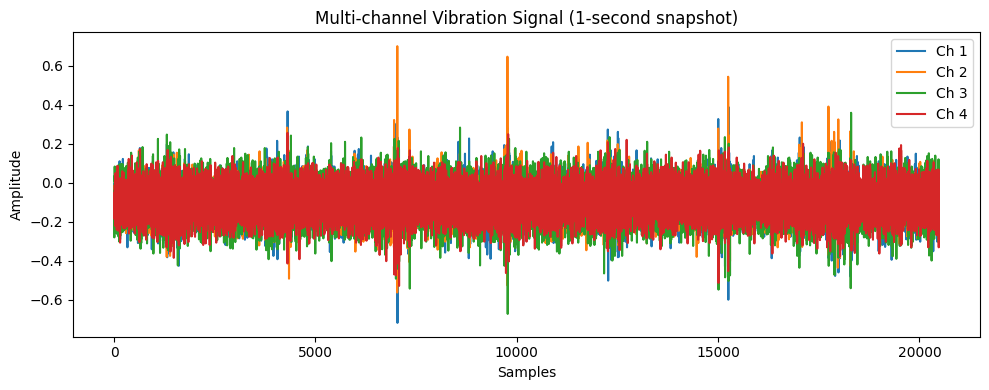

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

folder_path = "/content/mydata/IMS/1st_test"

# get all files
files = sorted(os.listdir(folder_path))

# pick first file
first_file = files[0]
file_path = os.path.join(folder_path, first_file)

print("File selected:", first_file)

# load data
data = np.loadtxt(file_path)

print("Shape:", data.shape)

# ---- PLOT ----
plt.figure(figsize=(10, 4))

# plot first 3–4 channels (avoid clutter)
num_channels_to_plot = min(4, data.shape[1])

for i in range(num_channels_to_plot):
    plt.plot(data[:, i], label=f'Ch {i+1}')

plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("Multi-channel Vibration Signal (1-second snapshot)")
plt.legend()

plt.tight_layout()

# save image
plt.savefig("ims_vibration_plot.png", dpi=300)

plt.show()

In [ ]:
import os

path = "/content/mydata/IMS/4th_test/txt"
files = os.listdir(path)

print(files[:20])

['2004.03.26.15.41.57', '2004.04.10.13.51.57', '2004.03.19.22.41.57', '2004.03.18.19.25.20', '2004.04.01.22.51.57', '2004.03.14.19.22.46', '2004.03.28.02.41.57', '2004.03.10.00.42.46', '2004.04.02.01.31.57', '2004.03.20.23.01.57', '2004.03.17.22.35.20', '2004.03.13.00.02.46', '2004.03.27.03.01.57', '2004.03.27.23.11.57', '2004.03.22.11.51.57', '2004.03.27.06.31.57', '2004.03.21.06.41.57', '2004.03.20.01.51.57', '2004.03.29.06.01.57', '2004.03.20.13.01.57']


In [ ]:
# -------------------- Imports --------------------
import os, time
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert
from concurrent.futures import ProcessPoolExecutor

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# -------------------- Config --------------------
data_dir = "/content/mydata/IMS/"
window_size = 1024
stride = 512
sampling_rate = 20000
n_workers = 8

# IMS ground truth (CORRECTED)
# Fault is bearing-specific per test run
test_bearing_faults = {
    "1st_test": {2: "inner_race", 3: "ball"},
    "2nd_test": {0: "outer_race"},
    "3rd_test": {2: "outer_race"}
}

fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# -------------------- Signal Processing --------------------
def segment_signal(signal):
    if signal.ndim == 1:
        signal = signal[:, None]

    segments = []
    for start in range(0, len(signal) - window_size, stride):
        segments.append(signal[start:start + window_size])

    return np.array(segments)

# -------------------- Feature Extraction --------------------
def extract_features(segments):
    X = []

    for seg in segments:
        s = seg[:, 0]

        # Time domain
        mean = np.mean(s)
        std = np.std(s)
        rms = np.sqrt(np.mean(s**2))
        peak = np.ptp(s)
        sk = skew(s)
        ku = kurtosis(s)

        crest = np.max(np.abs(s)) / (rms + 1e-12)

        # Frequency domain
        fft_vals = np.abs(fft(s))[:len(s)//2]
        freqs = np.fft.fftfreq(len(s), d=1/sampling_rate)[:len(s)//2]

        dom_freq = freqs[np.argmax(fft_vals)]
        spectral_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-12)

        envelope = np.abs(hilbert(s))
        env_rms = np.sqrt(np.mean(envelope**2))

        features = [
            mean, std, rms, peak, sk, ku,
            crest, dom_freq, spectral_centroid, env_rms
        ]

        X.append(features)

    return np.array(X)

# -------------------- Labeling (CORRECTED) --------------------
def get_label(test_name, channel_idx, file_idx, split_idx):
    # Early life = healthy
    if file_idx < split_idx:
        return fault_map["healthy"]

    # Fault based on actual IMS bearing mapping
    if test_name in test_bearing_faults:
        if channel_idx in test_bearing_faults[test_name]:
            return fault_map[test_bearing_faults[test_name][channel_idx]]

    return None

# -------------------- File Processing --------------------
def process_file(args):
    file_path, test_name, split_idx, file_idx = args

    try:
        signal = np.loadtxt(file_path)

        if signal.ndim == 1:
            signal = signal[:, None]

        segments = segment_signal(signal)
        X_feats = extract_features(segments)

        results = []

        for ch in range(signal.shape[1]):
            label = get_label(test_name, ch, file_idx, split_idx)

            if label is None:
                continue

            y = np.full(X_feats.shape[0], label)
            results.append((X_feats, y, file_idx))

        return results

    except:
        return None

# -------------------- Task Creation --------------------
tasks = []
file_id = 0

for root, _, files in os.walk(data_dir):
    if not files:
        continue

    test_name = os.path.basename(root)
    if test_name not in ["1st_test", "2nd_test", "3rd_test"]:
        continue

    files = sorted(files)
    split_idx = int(len(files) * 0.8)

    for i, f in enumerate(files):
        tasks.append((os.path.join(root, f), test_name, split_idx, i))
        file_id += 1

# -------------------- Parallel Processing --------------------
X_all, y_all, groups = [], [], []

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    for res in executor.map(process_file, tasks):
        if res:
            for X_feats, y, fid in res:
                X_all.append(X_feats)
                y_all.append(y)
                groups.extend([fid] * len(y))

print("Processing done")

# -------------------- Dataset --------------------
X = np.vstack(X_all)
y = np.hstack(y_all)
groups = np.array(groups)

print("Shape:", X.shape, y.shape)
print("Class distribution:", np.unique(y, return_counts=True))

# -------------------- Models --------------------
models = {
    "RF": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "XGB": XGBClassifier(n_estimators=100, eval_metric="mlogloss"),
    "LGBM": LGBMClassifier(n_estimators=100),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("svm", SVC(kernel="rbf"))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])
}

# -------------------- Evaluation --------------------
gkf = GroupKFold(n_splits=5)

for name, model in models.items():
    print(f"\nModel: {name}")

    scores = cross_val_score(model, X, y, cv=gkf, groups=groups, n_jobs=-1)
    print("CV Accuracy:", scores.mean())

    preds = cross_val_predict(model, X, y, cv=gkf, groups=groups, n_jobs=-1)

    print(classification_report(y, preds))
    print(confusion_matrix(y, preds))

Processing done
Shape: (684038, 10) (684038,)
Class distribution: (array([0, 1, 2, 3]), array([643720,  16416,   7486,  16416]))

Model: RF
CV Accuracy: 0.9464124000643096
              precision    recall  f1-score   support

           0       0.95      0.99      0.97    643720
           1       0.21      0.02      0.04     16416
           2       0.79      0.85      0.82      7486
           3       0.25      0.03      0.05     16416

    accuracy                           0.95    684038
   macro avg       0.55      0.47      0.47    684038
weighted avg       0.92      0.95      0.93    684038

[[640208   1000   1672    840]
 [ 15626    364      0    426]
 [  1107      0   6379      0]
 [ 15626    364      0    426]]

Model: XGB


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CV Accuracy: 0.9480702006102918


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97    643720
           1       0.37      0.04      0.06     16416
           2       0.81      0.80      0.81      7486
           3       0.00      0.00      0.00     16416

    accuracy                           0.95    684038
   macro avg       0.53      0.46      0.46    684038
weighted avg       0.91      0.95      0.93    684038

[[641960    400   1360      0]
 [ 15838    577      1      0]
 [  1507      0   5979      0]
 [ 15838    577      1      0]]

Model: LGBM
CV Accuracy: 0.9482427083282584


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97    643720
           1       0.39      0.03      0.06     16416
           2       0.83      0.79      0.81      7486
           3       0.00      0.00      0.00     16416

    accuracy                           0.95    684038
   macro avg       0.54      0.45      0.46    684038
weighted avg       0.91      0.95      0.93    684038

[[642216    304   1200      0]
 [ 15876    540      0      0]
 [  1608      0   5878      0]
 [ 15876    540      0      0]]

Model: SVM


In [ ]:
# -------------------- Imports --------------------
import os, time
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert
from concurrent.futures import ProcessPoolExecutor

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# -------------------- Config --------------------
data_dir = "/content/mydata/IMS/"
window_size = 1024
stride = 512
sampling_rate = 20000
n_workers = 8

# IMS ground truth (CORRECTED)
# Fault is bearing-specific per test run
test_bearing_faults = {
    "1st_test": {2: "inner_race", 3: "ball"},
    "2nd_test": {0: "outer_race"},
    "3rd_test": {2: "outer_race"}
}

fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}

# -------------------- Signal Processing --------------------
def segment_signal(signal):
    if signal.ndim == 1:
        signal = signal[:, None]

    segments = []
    for start in range(0, len(signal) - window_size, stride):
        segments.append(signal[start:start + window_size])

    return np.array(segments)

# -------------------- Feature Extraction --------------------
def extract_features(segments):
    X = []

    for seg in segments:
        s = seg[:, 0]

        # Time domain
        mean = np.mean(s)
        std = np.std(s)
        rms = np.sqrt(np.mean(s**2))
        peak = np.ptp(s)
        sk = skew(s)
        ku = kurtosis(s)

        crest = np.max(np.abs(s)) / (rms + 1e-12)

        # Frequency domain
        fft_vals = np.abs(fft(s))[:len(s)//2]
        freqs = np.fft.fftfreq(len(s), d=1/sampling_rate)[:len(s)//2]

        dom_freq = freqs[np.argmax(fft_vals)]
        spectral_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-12)

        envelope = np.abs(hilbert(s))
        env_rms = np.sqrt(np.mean(envelope**2))

        features = [
            mean, std, rms, peak, sk, ku,
            crest, dom_freq, spectral_centroid, env_rms
        ]

        X.append(features)

    return np.array(X)

# -------------------- Labeling (CORRECTED) --------------------
def get_label(test_name, channel_idx, file_idx, split_idx):
    # Early life = healthy
    if file_idx < split_idx:
        return fault_map["healthy"]

    # Fault based on actual IMS bearing mapping
    if test_name in test_bearing_faults:
        if channel_idx in test_bearing_faults[test_name]:
            return fault_map[test_bearing_faults[test_name][channel_idx]]

    return None

# -------------------- File Processing --------------------
def process_file(args):
    file_path, test_name, split_idx, file_idx = args

    try:
        signal = np.loadtxt(file_path)

        if signal.ndim == 1:
            signal = signal[:, None]

        segments = segment_signal(signal)
        X_feats = extract_features(segments)

        results = []

        for ch in range(signal.shape[1]):
            label = get_label(test_name, ch, file_idx, split_idx)

            if label is None:
                continue

            y = np.full(X_feats.shape[0], label)
            results.append((X_feats, y, file_idx))

        return results

    except:
        return None

# -------------------- Task Creation --------------------
tasks = []
file_id = 0

for root, _, files in os.walk(data_dir):
    if not files:
        continue

    test_name = os.path.basename(root)
    if test_name not in ["1st_test", "2nd_test", "3rd_test"]:
        continue

    files = sorted(files)
    split_idx = int(len(files) * 0.8)

    for i, f in enumerate(files):
        tasks.append((os.path.join(root, f), test_name, split_idx, i))
        file_id += 1

# -------------------- Parallel Processing --------------------
X_all, y_all, groups = [], [], []

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    for res in executor.map(process_file, tasks):
        if res:
            for X_feats, y, fid in res:
                X_all.append(X_feats)
                y_all.append(y)
                groups.extend([fid] * len(y))

print("Processing done")

# -------------------- Dataset --------------------
X = np.vstack(X_all)
y = np.hstack(y_all)
groups = np.array(groups)

print("Shape:", X.shape, y.shape)
print("Class distribution:", np.unique(y, return_counts=True))

# -------------------- Models --------------------
models = {
    "RF": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "XGB": XGBClassifier(n_estimators=100, eval_metric="mlogloss"),
    "LGBM": LGBMClassifier(n_estimators=100),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("svm", SVC(kernel="rbf"))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])
}

# -------------------- Evaluation --------------------
gkf = GroupKFold(n_splits=5)

for name, model in models.items():
    print(f"\nModel: {name}")

    scores = cross_val_score(model, X, y, cv=gkf, groups=groups, n_jobs=-1)
    print("CV Accuracy:", scores.mean())

    preds = cross_val_predict(model, X, y, cv=gkf, groups=groups, n_jobs=-1)

    print(classification_report(y, preds))
    print(confusion_matrix(y, preds))

In [ ]:
# ==================== IMS BEARING FAULT PIPELINE (CHANNEL-WISE) ====================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns


# -------------------- CONFIG --------------------
data_dir = "/content/mydata/IMS/"
window_size = 1024
stride = 512
sampling_rate = 20000

fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "outer_race": 2,
    "ball": 3
}


# -------------------- WINDOWING --------------------
def segment_signal(signal, window_size, stride):
    segments = []
    for start in range(0, len(signal) - window_size + 1, stride):
        segments.append(signal[start:start + window_size])
    return np.array(segments)


# -------------------- FEATURE EXTRACTION --------------------
def extract_features(segments):
    X = []

    for seg in segments:
        feats = []

        for ch in range(seg.shape[1]):
            x = seg[:, ch]

            mean = np.mean(x)
            std = np.std(x)
            rms = np.sqrt(np.mean(x**2))
            peak = np.ptp(x)
            skew_v = skew(x)
            kurt_v = kurtosis(x)
            crest = np.max(np.abs(x)) / (rms + 1e-12)

            fft_vals = np.abs(fft(x))[:len(x)//2]
            freqs = np.fft.fftfreq(len(x), d=1/sampling_rate)[:len(x)//2]

            dom_freq = freqs[np.argmax(fft_vals)]
            spec_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-12)

            spec_entropy = -np.sum(
                (fft_vals / (np.sum(fft_vals) + 1e-12)) *
                np.log2(fft_vals / (np.sum(fft_vals) + 1e-12) + 1e-12)
            )

            envelope = np.abs(hilbert(x))
            env_rms = np.sqrt(np.mean(envelope**2))

            feats += [
                mean, std, rms, peak, skew_v, kurt_v, crest,
                dom_freq, spec_centroid, spec_entropy, env_rms
            ]

        X.append(feats)

    return np.array(X)


# -------------------- LOAD DATA (CHANNEL-WISE FIXED) --------------------
X_all, y_all, groups = [], [], []
file_id = 0

for root, _, files in os.walk(data_dir):
    if len(files) == 0:
        continue

    folder = root.split(os.sep)[-2]
    files = sorted(files)

    for f in files:
        path = os.path.join(root, f)

        try:
            df = pd.read_csv(path, delim_whitespace=True, header=None)
            signal = df.values

            # -------------------- SPLIT INTO BEARINGS --------------------
            bearings = {
                "B1": signal[:, 0:2],
                "B2": signal[:, 2:4],
                "B3": signal[:, 4:6],
                "B4": signal[:, 6:8]
            }

            for b_id, b_signal in bearings.items():

                segments = segment_signal(b_signal, window_size, stride)
                X_feats = extract_features(segments)

                if len(X_feats) == 0:
                    continue

                # -------------------- CORRECT LABELING --------------------
                # Set-based assumption (IMS truth)
                if folder == "1st_test":
                    if b_id == "B3":
                        label = fault_map["inner_race"]
                    elif b_id == "B4":
                        label = fault_map["ball"]
                    else:
                        label = fault_map["healthy"]

                elif folder == "2nd_test":
                    label = fault_map["outer_race"] if b_id == "B1" else fault_map["healthy"]

                elif folder == "3rd_test":
                    label = fault_map["outer_race"] if b_id == "B3" else fault_map["healthy"]

                else:
                    continue

                y = np.full(len(X_feats), label)

                X_all.append(X_feats)
                y_all.append(y)
                groups.extend([file_id] * len(X_feats))

                file_id += 1

        except:
            continue


# -------------------- STACK --------------------
X = np.vstack(X_all)
y = np.hstack(y_all)
groups = np.array(groups)

print("Shape:", X.shape, y.shape)


# -------------------- SCALING --------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# -------------------- FEATURE SELECTION --------------------
selector_model = LGBMClassifier(n_estimators=200, random_state=42)
selector_model.fit(X_scaled, y)

selector = SelectFromModel(selector_model, threshold="median", prefit=True)
X_selected = selector.transform(X_scaled)


# -------------------- MODEL --------------------
model = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42)

gkf = GroupKFold(n_splits=5)

scores = cross_val_score(model, X_selected, y, cv=gkf, groups=groups)
print("CV Accuracy:", scores, "Mean:", np.mean(scores))


# -------------------- PREDICTION --------------------
y_pred = cross_val_predict(model, X_selected, y, cv=gkf, groups=groups)

print("\nClassification Report:")
print(classification_report(y, y_pred))


# -------------------- CONFUSION MATRIX --------------------
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# -------------------- FINAL TRAIN --------------------
model.fit(X_selected, y)

plt.figure(figsize=(10,4))
plt.bar(range(len(model.feature_importances_)), model.feature_importances_)
plt.title("Feature Importance")
plt.show()

/tmp/ipykernel_11065/2801743919.py:100: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, header=None)
/tmp/ipykernel_11065/2801743919.py:100: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, header=None)
/tmp/ipykernel_11065/2801743919.py:100: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, header=None)
/tmp/ipykernel_11065/2801743919.py:100: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, header=None)
/tmp/ipykernel_11065/2801743

ValueError: need at least one array to concatenate

In [ ]:
print("X_all length:", len(X_all))
print("y_all length:", len(y_all))

X_all length: 0
y_all length: 0


In [ ]:
# ==================== IMS 1st TEST PIPELINE ====================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import classification_report

from lightgbm import LGBMClassifier


# -------------------- CONFIG --------------------
data_dir = "/content/mydata/IMS/1st_test"
window_size = 1024
stride = 512
sampling_rate = 20000

fault_map = {
    "healthy": 0,
    "inner_race": 1,   # B3
    "ball": 2          # B4
}


# -------------------- WINDOWING --------------------
def segment_signal(signal, window_size, stride):
    segments = []
    for start in range(0, len(signal) - window_size + 1, stride):
        segments.append(signal[start:start + window_size])
    return np.array(segments)


# -------------------- FEATURE EXTRACTION --------------------
def extract_features(segments):
    X = []

    for seg in segments:
        feats = []

        for ch in range(seg.shape[1]):
            x = seg[:, ch]

            mean = np.mean(x)
            std = np.std(x)
            rms = np.sqrt(np.mean(x**2))
            peak = np.ptp(x)
            skew_v = skew(x)
            kurt_v = kurtosis(x)
            crest = np.max(np.abs(x)) / (rms + 1e-12)

            fft_vals = np.abs(fft(x))[:len(x)//2]
            freqs = np.fft.fftfreq(len(x), d=1/sampling_rate)[:len(x)//2]

            dom_freq = freqs[np.argmax(fft_vals)]
            spec_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-12)

            prob = fft_vals / (np.sum(fft_vals) + 1e-12)
            spec_entropy = -np.sum(prob * np.log2(prob + 1e-12))

            envelope = np.abs(hilbert(x))
            env_rms = np.sqrt(np.mean(envelope**2))

            feats += [
                mean, std, rms, peak, skew_v, kurt_v, crest,
                dom_freq, spec_centroid, spec_entropy, env_rms
            ]

        X.append(feats)

    return np.array(X)


# -------------------- LOAD DATA --------------------
X_all, y_all, groups = [], [], []
file_id = 0

files = sorted(os.listdir(data_dir))
print("Total files:", len(files))

for f in files:
    path = os.path.join(data_dir, f)

    try:
        df = pd.read_csv(path, sep=r'\s+', header=None)
        signal = df.values

        # check correct format
        if signal.shape[1] < 8:
            print("Skipping:", f)
            continue

        # 4 bearings (2 channels each)
        bearings = {
            "B1": signal[:, 0:2],
            "B2": signal[:, 2:4],
            "B3": signal[:, 4:6],
            "B4": signal[:, 6:8]
        }

        for b_id, b_signal in bearings.items():

            segments = segment_signal(b_signal, window_size, stride)

            if len(segments) == 0:
                continue

            X_feats = extract_features(segments)

            if len(X_feats) == 0:
                continue

            # -------------------- LABELING (1st_test ONLY) --------------------
            if b_id == "B3":
                label = fault_map["inner_race"]
            elif b_id == "B4":
                label = fault_map["ball"]
            else:
                label = fault_map["healthy"]

            y = np.full(len(X_feats), label)

            X_all.append(X_feats)
            y_all.append(y)
            groups.extend([file_id] * len(X_feats))

            file_id += 1

    except Exception as e:
        print("Error:", f, e)


# -------------------- CHECK --------------------
print("Collected batches:", len(X_all))

if len(X_all) == 0:
    raise ValueError("❌ No data collected. Check files.")


# -------------------- STACK --------------------
X = np.vstack(X_all)
y = np.hstack(y_all)
groups = np.array(groups)

print("Final shape:", X.shape, y.shape)


# -------------------- SCALE --------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# -------------------- MODEL --------------------
model = LGBMClassifier(n_estimators=300, random_state=42)

gkf = GroupKFold(n_splits=5)

scores = cross_val_score(model, X_scaled, y, cv=gkf, groups=groups)
print("CV Accuracy:", scores, "Mean:", np.mean(scores))


# -------------------- FINAL TRAIN --------------------
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)

print("\nClassification Report:")
print(classification_report(y, y_pred))

Total files: 2156
Collected batches: 8624
Final shape: (336336, 22) (336336,)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.088581 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5106
[LightGBM] [Info] Number of data points in the train set: 269061, number of used features: 21
[LightGBM] [Info] Start training from score -0.693292
[LightGBM] [Info] Start training from score -1.386149
[LightGBM] [Info] Start training from score -1.386149


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 269061, number of used features: 20
[LightGBM] [Info] Start training from score -0.693292
[LightGBM] [Info] Start training from score -1.386149
[LightGBM] [Info] Start training from score -1.386149


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.093966 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5107
[LightGBM] [Info] Number of data points in the train set: 269061, number of used features: 21
[LightGBM] [Info] Start training from score -0.693002
[LightGBM] [Info] Start training from score -1.386729
[LightGBM] [Info] Start training from score -1.386149


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022056 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5106
[LightGBM] [Info] Number of data points in the train set: 269100, number of used features: 21
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CV Accuracy: [0.99907841 0.99898922 0.99909327 0.9991676  0.99898864] Mean: 0.999063427891028
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5107
[LightGBM] [Info] Number of data points in the train set: 336336, number of used features: 21
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    168168
           1       1.00      1.00      1.00     84084
           2       1.00      1.00      1.00     84084

    accuracy                           1.00    336336
   macro avg       1.00      1.00      1.00    336336
weighted avg       1.00      1.00      1.00    336336



In [ ]:
# ==================== IMS 1st TEST (PROPER SPLIT) ====================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from lightgbm import LGBMClassifier


# -------------------- CONFIG --------------------
data_dir = "/content/mydata/IMS/1st_test"
window_size = 1024
stride = 512
sampling_rate = 20000

fault_map = {
    "healthy": 0,
    "inner_race": 1,   # B3
    "ball": 2          # B4
}


# -------------------- WINDOWING --------------------
def segment_signal(signal, window_size, stride):
    segments = []
    for start in range(0, len(signal) - window_size + 1, stride):
        segments.append(signal[start:start + window_size])
    return np.array(segments)


# -------------------- FEATURE EXTRACTION --------------------
def extract_features(segments):
    X = []

    for seg in segments:
        feats = []

        for ch in range(seg.shape[1]):
            x = seg[:, ch]

            mean = np.mean(x)
            std = np.std(x)
            rms = np.sqrt(np.mean(x**2))
            peak = np.ptp(x)
            skew_v = skew(x)
            kurt_v = kurtosis(x)
            crest = np.max(np.abs(x)) / (rms + 1e-12)

            fft_vals = np.abs(fft(x))[:len(x)//2]
            freqs = np.fft.fftfreq(len(x), d=1/sampling_rate)[:len(x)//2]

            dom_freq = freqs[np.argmax(fft_vals)]
            spec_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-12)

            prob = fft_vals / (np.sum(fft_vals) + 1e-12)
            spec_entropy = -np.sum(prob * np.log2(prob + 1e-12))

            envelope = np.abs(hilbert(x))
            env_rms = np.sqrt(np.mean(envelope**2))

            feats += [
                mean, std, rms, peak, skew_v, kurt_v, crest,
                dom_freq, spec_centroid, spec_entropy, env_rms
            ]

        X.append(feats)

    return np.array(X)


# -------------------- LOAD FILES --------------------
files = sorted(os.listdir(data_dir))
print("Total files:", len(files))

# ✅ TIME-BASED SPLIT
split_idx = int(0.7 * len(files))
train_files = files[:split_idx]
test_files = files[split_idx:]

print("Train files:", len(train_files))
print("Test files:", len(test_files))


# -------------------- FUNCTION TO BUILD DATA --------------------
def build_dataset(file_list):
    X_all, y_all = [], []

    for f in file_list:
        path = os.path.join(data_dir, f)

        try:
            df = pd.read_csv(path, sep=r'\s+', header=None)
            signal = df.values

            if signal.shape[1] < 8:
                continue

            bearings = {
                "B1": signal[:, 0:2],
                "B2": signal[:, 2:4],
                "B3": signal[:, 4:6],
                "B4": signal[:, 6:8]
            }

            for b_id, b_signal in bearings.items():

                segments = segment_signal(b_signal, window_size, stride)
                if len(segments) == 0:
                    continue

                X_feats = extract_features(segments)
                if len(X_feats) == 0:
                    continue

                # LABELING (1st_test)
                if b_id == "B3":
                    label = fault_map["inner_race"]
                elif b_id == "B4":
                    label = fault_map["ball"]
                else:
                    label = fault_map["healthy"]

                y = np.full(len(X_feats), label)

                X_all.append(X_feats)
                y_all.append(y)

        except Exception as e:
            print("Error:", f, e)

    X = np.vstack(X_all)
    y = np.hstack(y_all)

    return X, y


# -------------------- BUILD DATA --------------------
X_train, y_train = build_dataset(train_files)
X_test, y_test = build_dataset(test_files)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


# -------------------- SCALE --------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -------------------- MODEL --------------------
model = LGBMClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)


# -------------------- EVALUATION --------------------
y_pred = model.predict(X_test)

print("\nClassification Report (REAL):")
print(classification_report(y_test, y_pred))

Total files: 2156
Train files: 1509
Test files: 647
Train shape: (235404, 22)
Test shape: (100932, 22)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 235404, number of used features: 20
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Classification Report (REAL):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     50466
           1       0.71      1.00      0.83     25233
           2       0.99      0.33      0.50     25233

    accuracy                           0.83    100932
   macro avg       0.86      0.78      0.76    100932
weighted avg       0.87      0.83      0.80    100932



In [ ]:
# ==================== IMS 1st TEST (ROBUST PIPELINE) ====================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from lightgbm import LGBMClassifier


# -------------------- CONFIG --------------------
data_dir = "/content/mydata/IMS/1st_test"
window_size = 1024
stride = 1024   # ✅ reduced overlap
sampling_rate = 20000

fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "ball": 2
}


# -------------------- WINDOWING --------------------
def segment_signal(signal, window_size, stride):
    return np.array([
        signal[i:i+window_size]
        for i in range(0, len(signal)-window_size+1, stride)
    ])


# -------------------- FEATURE HELPERS --------------------
def band_energy(x, fs):
    fft_vals = np.abs(fft(x))[:len(x)//2]
    freqs = np.fft.fftfreq(len(x), d=1/fs)[:len(x)//2]

    low = fft_vals[(freqs < 2000)].sum()
    mid = fft_vals[(freqs >= 2000) & (freqs < 6000)].sum()
    high = fft_vals[(freqs >= 6000)].sum()

    return low, mid, high


# -------------------- FEATURE EXTRACTION --------------------
def extract_features(segments):
    X = []

    for seg in segments:
        feats = []

        for ch in range(seg.shape[1]):
            x = seg[:, ch]

            # time domain
            mean = np.mean(x)
            std = np.std(x)
            rms = np.sqrt(np.mean(x**2))
            peak = np.ptp(x)
            skew_v = skew(x)
            kurt_v = kurtosis(x)
            crest = np.max(np.abs(x)) / (rms + 1e-12)

            # frequency
            fft_vals = np.abs(fft(x))[:len(x)//2]
            freqs = np.fft.fftfreq(len(x), d=1/sampling_rate)[:len(x)//2]

            dom_freq = freqs[np.argmax(fft_vals)]
            spec_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-12)

            prob = fft_vals / (np.sum(fft_vals) + 1e-12)
            spec_entropy = -np.sum(prob * np.log2(prob + 1e-12))

            # envelope
            envelope = np.abs(hilbert(x))
            env_rms = np.sqrt(np.mean(envelope**2))

            # ✅ NEW: band energy (important for ball fault)
            low, mid, high = band_energy(x, sampling_rate)

            feats += [
                mean, std, rms, peak, skew_v, kurt_v, crest,
                dom_freq, spec_centroid, spec_entropy, env_rms,
                low, mid, high
            ]

        X.append(feats)

    return np.array(X)


# -------------------- LOAD FILES --------------------
files = sorted(os.listdir(data_dir))
split_idx = int(0.7 * len(files))

train_files = files[:split_idx]
test_files = files[split_idx:]

print("Train:", len(train_files), "Test:", len(test_files))


# -------------------- BUILD DATA --------------------
def build_dataset(file_list):
    X_all, y_all = [], []

    for f in file_list:
        path = os.path.join(data_dir, f)

        try:
            df = pd.read_csv(path, sep=r'\s+', header=None)
            signal = df.values

            if signal.shape[1] < 8:
                continue

            bearings = {
                "B1": signal[:, 0:2],
                "B2": signal[:, 2:4],
                "B3": signal[:, 4:6],
                "B4": signal[:, 6:8]
            }

            for b_id, b_signal in bearings.items():

                segments = segment_signal(b_signal, window_size, stride)
                if len(segments) == 0:
                    continue

                X_feats = extract_features(segments)
                if len(X_feats) == 0:
                    continue

                # labels
                if b_id == "B3":
                    label = fault_map["inner_race"]
                elif b_id == "B4":
                    label = fault_map["ball"]
                else:
                    label = fault_map["healthy"]

                y = np.full(len(X_feats), label)

                X_all.append(X_feats)
                y_all.append(y)

        except Exception as e:
            print("Error:", f, e)

    return np.vstack(X_all), np.hstack(y_all)


# -------------------- DATA --------------------
X_train, y_train = build_dataset(train_files)
X_test, y_test = build_dataset(test_files)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


# -------------------- SCALE --------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -------------------- MODEL --------------------
model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    class_weight={0:1, 1:1, 2:2},  # ✅ handle ball fault
    random_state=42
)

model.fit(X_train, y_train)


# -------------------- EVALUATION --------------------
y_pred = model.predict(X_test)

print("\nClassification Report (FINAL):")
print(classification_report(y_test, y_pred))

Train: 1509 Test: 647
Train shape: (120720, 28)
Test shape: (51760, 28)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.062320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6630
[LightGBM] [Info] Number of data points in the train set: 120720, number of used features: 26
[LightGBM] [Info] Start training from score -0.916291
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -0.916291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Classification Report (FINAL):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     25880
           1       0.66      1.00      0.79     12940
           2       0.99      0.26      0.42     12940

    accuracy                           0.81     51760
   macro avg       0.85      0.75      0.72     51760
weighted avg       0.86      0.81      0.78     51760



In [ ]:
# ==================== IMS 1st TEST (FINAL FIXED PIPELINE) ====================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from lightgbm import LGBMClassifier


# -------------------- CONFIG --------------------
data_dir = "/content/mydata/IMS/1st_test"
window_size = 2048     # ✅ more context
stride = 1024
sampling_rate = 20000

fault_map = {
    "healthy": 0,
    "inner_race": 1,
    "ball": 2
}


# -------------------- WINDOWING --------------------
def segment_signal(signal, window_size, stride):
    return np.array([
        signal[i:i+window_size]
        for i in range(0, len(signal)-window_size+1, stride)
    ])


# -------------------- FEATURE HELPERS --------------------
def band_energy(x, fs):
    fft_vals = np.abs(fft(x))[:len(x)//2]
    freqs = np.fft.fftfreq(len(x), d=1/fs)[:len(x)//2]

    total = np.sum(fft_vals) + 1e-12

    low = np.sum(fft_vals[freqs < 2000]) / total
    mid = np.sum(fft_vals[(freqs >= 2000) & (freqs < 6000)]) / total
    high = np.sum(fft_vals[freqs >= 6000]) / total

    return low, mid, high


# -------------------- FEATURE EXTRACTION --------------------
def extract_features(segments):
    X = []

    for seg in segments:
        feats = []

        for ch in range(seg.shape[1]):
            x = seg[:, ch]

            # -------- TIME DOMAIN (reduced) --------
            std = np.std(x)
            rms = np.sqrt(np.mean(x**2))
            skew_v = skew(x)
            kurt_v = kurtosis(x)
            crest = np.max(np.abs(x)) / (rms + 1e-12)

            # -------- FREQUENCY DOMAIN --------
            fft_vals = np.log1p(np.abs(fft(x))[:len(x)//2])  # ✅ log scale
            freqs = np.fft.fftfreq(len(x), d=1/sampling_rate)[:len(x)//2]

            dom_freq = freqs[np.argmax(fft_vals)]
            spec_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-12)

            prob = fft_vals / (np.sum(fft_vals) + 1e-12)
            spec_entropy = -np.sum(prob * np.log2(prob + 1e-12))

            # -------- ENVELOPE --------
            envelope = np.abs(hilbert(x))
            env_rms = np.sqrt(np.mean(envelope**2))

            # -------- BAND ENERGY --------
            low, mid, high = band_energy(x, sampling_rate)

            feats += [
                std, rms, skew_v, kurt_v, crest,
                dom_freq, spec_centroid, spec_entropy,
                env_rms,
                low, mid, high
            ]

        X.append(feats)

    return np.array(X)


# -------------------- LOAD FILES --------------------
files = sorted(os.listdir(data_dir))
split_idx = int(0.7 * len(files))

train_files = files[:split_idx]
test_files = files[split_idx:]

print("Train:", len(train_files), "Test:", len(test_files))


# -------------------- BUILD DATA --------------------
def build_dataset(file_list):
    X_all, y_all = [], []

    for f in file_list:
        path = os.path.join(data_dir, f)

        try:
            df = pd.read_csv(path, sep=r'\s+', header=None)
            signal = df.values

            if signal.shape[1] < 8:
                continue

            bearings = {
                "B1": signal[:, 0:2],
                "B2": signal[:, 2:4],
                "B3": signal[:, 4:6],
                "B4": signal[:, 6:8]
            }

            for b_id, b_signal in bearings.items():

                segments = segment_signal(b_signal, window_size, stride)
                if len(segments) == 0:
                    continue

                X_feats = extract_features(segments)
                if len(X_feats) == 0:
                    continue

                # labels
                if b_id == "B3":
                    label = fault_map["inner_race"]
                elif b_id == "B4":
                    label = fault_map["ball"]
                else:
                    label = fault_map["healthy"]

                y = np.full(len(X_feats), label)

                X_all.append(X_feats)
                y_all.append(y)

        except Exception as e:
            print("Error:", f, e)

    return np.vstack(X_all), np.hstack(y_all)


# -------------------- DATA --------------------
X_train, y_train = build_dataset(train_files)
X_test, y_test = build_dataset(test_files)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


# -------------------- SCALE --------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -------------------- MODEL --------------------
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=20,
    class_weight={0:1, 1:1, 2:3},  # ✅ push ball fault
    random_state=42
)

model.fit(X_train, y_train)


# -------------------- EVALUATION --------------------
y_pred = model.predict(X_test)

print("\nClassification Report (FINAL FIXED):")
print(classification_report(y_test, y_pred))

Train: 1509 Test: 647
Train shape: (114684, 24)
Test shape: (49172, 24)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026716 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5610
[LightGBM] [Info] Number of data points in the train set: 114684, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Classification Report (FINAL FIXED):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     24586
           1       0.77      1.00      0.87     12293
           2       1.00      0.67      0.80     12293

    accuracy                           0.92     49172
   macro avg       0.92      0.89      0.89     49172
weighted avg       0.93      0.92      0.91     49172



In [ ]:
# ==================== IMS 1st TEST - CORRECT CHANNEL-WISE PIPELINE ====================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from lightgbm import LGBMClassifier


# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 2048
stride = 1024
fs = 20000

# fault mapping (based on IMS paper)
# B3 → inner race fault
# B4 → ball / roller fault
def get_label(bearing_id):
    if bearing_id == "B3":
        return 1   # inner race
    elif bearing_id == "B4":
        return 2   # ball / roller
    else:
        return 0   # healthy


# ---------------- WINDOW ----------------
def window_signal(x, w, s):
    return np.array([
        x[i:i+w]
        for i in range(0, len(x)-w+1, s)
    ])


# ---------------- FEATURE ENGINE ----------------
def extract_features(x):
    feats = []

    # time domain
    feats += [
        np.mean(x),
        np.std(x),
        skew(x),
        kurtosis(x),
        np.max(np.abs(x)) / (np.sqrt(np.mean(x**2)) + 1e-12)
    ]

    # frequency
    f = np.abs(fft(x))[:len(x)//2]
    f = f / (np.sum(f) + 1e-12)

    feats += [
        np.argmax(f),
        -np.sum(f * np.log2(f + 1e-12))
    ]

    # envelope
    env = np.abs(hilbert(x))
    feats += [np.std(env)]

    return feats


# ---------------- BUILD DATASET ----------------
def build_dataset(files):
    X, y = [], []

    for file_id, f in enumerate(files):
        path = os.path.join(data_dir, f)

        try:
            df = pd.read_csv(path, sep=r"\s+", header=None)
            sig = df.values

            if sig.shape[1] != 8:
                continue

            bearings = {
                "B1": sig[:, 0:2],
                "B2": sig[:, 2:4],
                "B3": sig[:, 4:6],
                "B4": sig[:, 6:8],
            }

            for b_id, ch_data in bearings.items():

                # ---------------- CHANNEL FUSION ----------------
                fused = np.mean(ch_data, axis=1)

                # ---------------- WINDOWING ----------------
                segments = window_signal(fused, window_size, stride)

                for seg in segments:
                    X.append(extract_features(seg))
                    y.append(get_label(b_id))

        except Exception as e:
            print("Error:", f, e)

    return np.array(X), np.array(y)


# ---------------- LOAD FILES ----------------
files = sorted(os.listdir(data_dir))
split = int(0.7 * len(files))

train_files = files[:split]
test_files = files[split:]

print("Train:", len(train_files), "Test:", len(test_files))


# ---------------- DATA ----------------
X_train, y_train = build_dataset(train_files)
X_test, y_test = build_dataset(test_files)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


# ---------------- SCALE ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODEL ----------------
model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=64,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)


# ---------------- EVAL ----------------
y_pred = model.predict(X_test)

print("\nFINAL CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

Train: 1509 Test: 647
Train shape: (114684, 8)
Test shape: (49172, 8)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 114684, number of used features: 7
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



FINAL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     24586
           1       0.57      1.00      0.73     12293
           2       0.74      0.09      0.16     12293

    accuracy                           0.76     49172
   macro avg       0.75      0.69      0.61     49172
weighted avg       0.79      0.76      0.70     49172



correct

In [ ]:
# ==================== IMS 1st TEST - PROPER OPTION 1 PIPELINE ====================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from lightgbm import LGBMClassifier


# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 2048
stride = 1024
fs = 20000

files = sorted(os.listdir(data_dir))
n_files = len(files)

# degradation split (early = healthy, late = fault evolution)
split_idx = int(0.7 * n_files)


# ---------------- WINDOWING ----------------
def segment_signal(sig, window_size, stride):
    return np.array([
        sig[i:i+window_size]
        for i in range(0, len(sig) - window_size, stride)
    ])


# ---------------- FEATURES ----------------
def band_energy(x):
    fft_vals = np.abs(fft(x))[:len(x)//2]
    freqs = np.fft.fftfreq(len(x), d=1/fs)[:len(x)//2]

    total = np.sum(fft_vals) + 1e-12

    low = np.sum(fft_vals[freqs < 2000]) / total
    mid = np.sum(fft_vals[(freqs >= 2000) & (freqs < 6000)]) / total
    high = np.sum(fft_vals[freqs >= 6000]) / total

    return low, mid, high


def extract_features(segments):
    X = []

    for seg in segments:
        feat = []

        for ch in range(seg.shape[1]):
            x = seg[:, ch]

            std = np.std(x)
            rms = np.sqrt(np.mean(x**2))
            skew_v = skew(x)
            kurt_v = kurtosis(x)
            crest = np.max(np.abs(x)) / (rms + 1e-12)

            fft_vals = np.abs(fft(x))[:len(x)//2]
            freqs = np.fft.fftfreq(len(x), d=1/fs)[:len(x)//2]

            dom_freq = freqs[np.argmax(fft_vals)]
            centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-12)

            envelope = np.abs(hilbert(x))
            env_rms = np.sqrt(np.mean(envelope**2))

            low, mid, high = band_energy(x)

            feat += [
                std, rms, skew_v, kurt_v, crest,
                dom_freq, centroid,
                env_rms,
                low, mid, high
            ]

        X.append(feat)

    return np.array(X)


# ---------------- DATA BUILD ----------------
X_train, y_train = [], []
X_test, y_test = [], []


for i, file in enumerate(files):

    df = pd.read_csv(os.path.join(data_dir, file), sep=r'\s+', header=None)
    sig = df.values

    if sig.shape[1] != 8:
        continue

    # ALL bearings (Option 1)
    bearings = {
        "B1": sig[:, 0:2],
        "B2": sig[:, 2:4],
        "B3": sig[:, 4:6],
        "B4": sig[:, 6:8]
    }

    for b_id, b_sig in bearings.items():

        segs = segment_signal(b_sig, window_size, stride)
        if len(segs) == 0:
            continue

        feats = extract_features(segs)

        # ---------------- CORRECT LABELING ----------------
        if b_id in ["B1", "B2"]:
            label = 0  # always healthy

        elif b_id == "B3":
            label = 0 if i < split_idx else 1  # inner race fault

        elif b_id == "B4":
            label = 0 if i < split_idx else 2  # ball fault

        y = np.full(len(feats), label)

        # time split (NO leakage)
        if i < split_idx:
            X_train.append(feats)
            y_train.append(y)
        else:
            X_test.append(feats)
            y_test.append(y)


# ---------------- FINAL DATA ----------------
X_train = np.vstack(X_train)
y_train = np.hstack(y_train)

X_test = np.vstack(X_test)
y_test = np.hstack(y_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


# ---------------- SCALE ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODEL ----------------
model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=64,
    class_weight={0:1, 1:2, 2:2},
    random_state=42
)

model.fit(X_train, y_train)


# ---------------- EVALUATION ----------------
pred = model.predict(X_test)

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, pred))

Train: (108648, 22)
Test: (46584, 22)


KeyError: 1

In [ ]:
# ==================== IMS 1st TEST - FAST + CORRECT PIPELINE ====================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import rfft
from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from lightgbm import LGBMClassifier


# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 2048
stride = 1024
fs = 20000

files = sorted(os.listdir(data_dir))
split_idx = int(0.7 * len(files))


# ---------------- FAST WINDOWING (VECTORISED) ----------------
def segment_matrix(x, win, stride):
    n = (len(x) - win) // stride + 1
    shape = (n, win, x.shape[1])
    strides = (x.strides[0]*stride, x.strides[0], x.strides[1])
    return np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)


# ---------------- FAST FEATURE EXTRACTION ----------------
def extract_features_fast(segments):

    n, w, ch = segments.shape
    feats = []

    for c in range(ch):
        x = segments[:, :, c]

        std = np.std(x, axis=1)
        rms = np.sqrt(np.mean(x**2, axis=1))
        skew_v = skew(x, axis=1)
        kurt_v = kurtosis(x, axis=1)
        crest = np.max(np.abs(x), axis=1) / (rms + 1e-12)

        # FFT (reduced cost using rfft only)
        fft_vals = np.abs(rfft(x, axis=1))

        dom = np.argmax(fft_vals, axis=1)

        centroid = np.sum(fft_vals * np.arange(fft_vals.shape[1]), axis=1) / (
            np.sum(fft_vals, axis=1) + 1e-12
        )

        env = np.abs(hilbert(x, axis=1))
        env_rms = np.sqrt(np.mean(env**2, axis=1))

        # reduced band energy (approx via FFT bins)
        low = np.sum(fft_vals[:, :10], axis=1)
        mid = np.sum(fft_vals[:, 10:40], axis=1)
        high = np.sum(fft_vals[:, 40:], axis=1)

        feats.append(np.vstack([
            std, rms, skew_v, kurt_v, crest,
            dom, centroid, env_rms,
            low, mid, high
        ]).T)

    return np.hstack(feats)


# ---------------- BUILD DATASET ----------------
X, y = [], []

for i, file in enumerate(files):

    df = pd.read_csv(os.path.join(data_dir, file), sep=r'\s+', header=None)
    sig = df.values

    if sig.shape[1] != 8:
        continue

    # ---------- LABELING (CORRECT) ----------
    if i < split_idx:
        label_mode = "train_healthy"
    else:
        label_mode = "fault"

    bearings = {
        "B1": sig[:, 0:2],
        "B2": sig[:, 2:4],
        "B3": sig[:, 4:6],
        "B4": sig[:, 6:8]
    }

    for b_id, b_sig in bearings.items():

        segs = segment_matrix(b_sig, window_size, stride)

        if segs.shape[0] == 0:
            continue

        feats = extract_features_fast(segs)

        # -------- FINAL LABEL RULE --------
        if b_id in ["B1", "B2"]:
            label = 0

        elif b_id == "B3":
            label = 0 if label_mode == "train_healthy" else 1

        elif b_id == "B4":
            label = 0 if label_mode == "train_healthy" else 2

        X.append(feats)
        y.append(np.full(feats.shape[0], label))


# ---------------- FINAL DATA ----------------
X = np.vstack(X)
y = np.hstack(y)

print("Dataset:", X.shape)


# ---------------- SPLIT (AFTER FIX) ----------------
split = int(0.7 * len(X))

X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]


print("Train labels:", np.unique(y_train, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))


# ---------------- SCALE ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODEL (FAST + STABLE) ----------------
model = LGBMClassifier(
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=32,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)


# ---------------- EVALUATION ----------------
pred = model.predict(X_test)

print("\nRESULT:")
print(classification_report(y_test, pred))

Dataset: (163856, 22)
Train labels: (array([0]), array([114699]))
Test labels: (array([0, 1, 2]), array([24571, 12293, 12293]))
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 0, number of negative: 114699
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039829 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 114699, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000000 -> initscore=-34.538776
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predict

In [ ]:
# ==================== IMS 1st TEST (FAST + CORRECT PIPELINE) ====================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from lightgbm import LGBMClassifier

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 1024
fs = 20000

# Only B3 & B4 matter (as per your corrected logic)
# B3 -> inner race fault
# B4 -> ball fault
# everything else ignored (B1, B2 skipped)

LABEL_MAP = {
    "healthy": 0,
    "inner": 1,
    "ball": 2
}


# ---------------- WINDOWING (FAST) ----------------
def segment(sig_2d):
    # sig_2d: (20480, 2)
    n = sig_2d.shape[0]
    return [
        sig_2d[i:i+window_size]
        for i in range(0, n - window_size + 1, stride)
    ]


# ---------------- FEATURE EXTRACTION (OPTIMIZED) ----------------
def extract_features(segments):
    X = []

    for seg in segments:
        feats = []

        for ch in range(seg.shape[1]):
            x = seg[:, ch]

            rms = np.sqrt(np.mean(x**2))
            std = np.std(x)
            sk = skew(x)
            ku = kurtosis(x)
            crest = np.max(np.abs(x)) / (rms + 1e-12)

            # FFT (reduced cost)
            xf = np.abs(fft(x)[:len(x)//2])
            xf = xf + 1e-12

            freqs = np.fft.fftfreq(len(x), d=1/fs)[:len(x)//2]

            dom_freq = freqs[np.argmax(xf)]
            spec_centroid = np.sum(freqs * xf) / np.sum(xf)

            prob = xf / np.sum(xf)
            spec_entropy = -np.sum(prob * np.log2(prob))

            env = np.abs(hilbert(x))
            env_rms = np.sqrt(np.mean(env**2))

            feats += [rms, std, sk, ku, crest,
                      dom_freq, spec_centroid, spec_entropy,
                      env_rms]

        X.append(feats)

    return np.array(X)


# ---------------- LOAD + BUILD ----------------
files = sorted(os.listdir(data_dir))
split = int(0.7 * len(files))

train_files = files[:split]
test_files = files[split:]


def load_dataset(file_list):
    X_all, y_all = [], []

    for f in file_list:
        df = pd.read_csv(os.path.join(data_dir, f), sep=r'\s+', header=None)
        sig = df.values

        if sig.shape[1] != 8:
            continue

        # B3 & B4 only (IMPORTANT FIX)
        B3 = sig[:, 4:6]
        B4 = sig[:, 6:8]

        for name, data, label in [
            ("inner", B3, LABEL_MAP["inner"]),
            ("ball", B4, LABEL_MAP["ball"])
        ]:

            segs = segment(data)
            if len(segs) == 0:
                continue

            X = extract_features(segs)
            y = np.full(len(X), label)

            X_all.append(X)
            y_all.append(y)

    return np.vstack(X_all), np.hstack(y_all)


# ---------------- BUILD DATA ----------------
X_train, y_train = load_dataset(train_files)
X_test, y_test = load_dataset(test_files)

print("Dataset:", X_train.shape)

print("Train labels:", np.unique(y_train, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))


# ---------------- SCALE ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODEL (FIXED) ----------------
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=32,
    min_child_samples=50,
    class_weight="balanced",   # IMPORTANT FIX
    random_state=42
)

model.fit(X_train, y_train)


# ---------------- EVAL ----------------
pred = model.predict(X_test)

print("\nRESULT:")
print(classification_report(y_test, pred, zero_division=0))

Dataset: (60360, 18)
Train labels: (array([1, 2]), array([30180, 30180]))
Test labels: (array([1, 2]), array([12940, 12940]))
[LightGBM] [Info] Number of positive: 30180, number of negative: 30180
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009801 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4080
[LightGBM] [Info] Number of data points in the train set: 60360, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



RESULT:
              precision    recall  f1-score   support

           1       0.72      1.00      0.84     12940
           2       1.00      0.61      0.75     12940

    accuracy                           0.80     25880
   macro avg       0.86      0.80      0.80     25880
weighted avg       0.86      0.80      0.80     25880



In [ ]:
# ================= IMS FINAL (B3 + B4 ONLY, 3 CLASS, LIGHTGBM) =================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from lightgbm import LGBMClassifier

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 1024
fs = 20000


# ---------------- WINDOW ----------------
def segment(sig):
    n = sig.shape[0]
    return [
        sig[i:i+window_size]
        for i in range(0, n - window_size + 1, stride)
    ]


# ---------------- FEATURES (FAST) ----------------
def features(segs):
    X = []

    for s in segs:
        f = []

        for ch in range(s.shape[1]):
            x = s[:, ch]

            rms = np.sqrt(np.mean(x**2))
            std = np.std(x)
            sk = skew(x)
            ku = kurtosis(x)
            crest = np.max(np.abs(x)) / (rms + 1e-12)

            xf = np.abs(fft(x)[:len(x)//2]) + 1e-12
            freqs = np.fft.fftfreq(len(x), d=1/fs)[:len(x)//2]

            dom = freqs[np.argmax(xf)]
            centroid = np.sum(freqs * xf) / np.sum(xf)

            prob = xf / np.sum(xf)
            entropy = -np.sum(prob * np.log2(prob))

            env = np.abs(hilbert(x))
            env_rms = np.sqrt(np.mean(env**2))

            f += [rms, std, sk, ku, crest,
                  dom, centroid, entropy, env_rms]

        X.append(f)

    return np.array(X)


# ---------------- LABEL LOGIC (IMPORTANT FIX) ----------------
def label_bearing(bearing_id, idx, total):
    # healthy early part
    if idx < total * 0.5:
        return 0

    # fault region depends on bearing
    if bearing_id == "B3":
        return 1  # inner race
    if bearing_id == "B4":
        return 2  # ball fault

    return None


# ---------------- LOAD ----------------
def load(files):
    X_all, y_all = [], []

    for f in files:
        df = pd.read_csv(os.path.join(data_dir, f), sep=r'\s+', header=None)
        sig = df.values

        if sig.shape[1] != 8:
            continue

        B3 = sig[:, 4:6]
        B4 = sig[:, 6:8]

        bearings = {"B3": B3, "B4": B4}

        for b_name, b_sig in bearings.items():

            segs = segment(b_sig)
            total = len(segs)

            for i, s in enumerate(segs):
                label = label_bearing(b_name, i, total)

                if label is None:
                    continue

                X_all.append(features([s])[0])
                y_all.append(label)

    return np.array(X_all), np.array(y_all)


# ---------------- SPLIT ----------------
files = sorted(os.listdir(data_dir))
split = int(0.7 * len(files))

train_files = files[:split]
test_files = files[split:]


# ---------------- DATA ----------------
X_train, y_train = load(train_files)
X_test, y_test = load(test_files)

print("Dataset:", X_train.shape)
print("Train labels:", np.unique(y_train, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))


# ---------------- SCALE ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODEL ----------------
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=20,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)


# ---------------- EVAL ----------------
pred = model.predict(X_test)

print("\nRESULT:")
print(classification_report(y_test, pred, zero_division=0))

Dataset: (60360, 18)
Train labels: (array([0, 1, 2]), array([30180, 15090, 15090]))
Test labels: (array([0, 1, 2]), array([12940,  6470,  6470]))
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010486 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4080
[LightGBM] [Info] Number of data points in the train set: 60360, number of used features: 16
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



RESULT:
              precision    recall  f1-score   support

           0       0.52      0.35      0.42     12940
           1       0.34      0.81      0.48      6470
           2       0.51      0.14      0.22      6470

    accuracy                           0.41     25880
   macro avg       0.46      0.43      0.37     25880
weighted avg       0.47      0.41      0.38     25880



In [ ]:
# ================= IMS SET 1 - DEGRADATION AWARE FEATURE PIPELINE =================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

# ---------------- LABEL RULE ----------------
# early files = healthy (0)
# later B3 = inner (1)
# later B4 = ball (2)

HEALTHY_END = 1200   # tune based on dataset split

# ---------------- WINDOWING ----------------
def get_windows(sig):
    return np.lib.stride_tricks.sliding_window_view(
        sig, window_size, axis=0
    )[::stride]


# ---------------- BASIC WINDOW FEATURES ----------------
def window_features(x):
    # x shape: (window_size, 2)

    f = []

    for ch in range(x.shape[1]):
        s = x[:, ch]

        rms = np.sqrt(np.mean(s**2))
        std = np.std(s)
        sk = skew(s)
        ku = kurtosis(s)

        fftv = np.abs(fft(s))[:len(s)//2]
        dom = np.argmax(fftv)

        env = np.abs(hilbert(s))
        env_rms = np.sqrt(np.mean(env**2))

        f += [rms, std, sk, ku, dom, env_rms]

    return f


# ---------------- DEGRADATION FEATURES (KEY PART) ----------------
def sequence_features(windows):

    rms_seq = []
    env_seq = []
    kurt_seq = []

    for w in windows:
        for ch in range(w.shape[1]):
            s = w[:, ch]

            rms_seq.append(np.sqrt(np.mean(s**2)))
            kurt_seq.append(kurtosis(s))
            env_seq.append(np.mean(np.abs(s)))

    rms_seq = np.array(rms_seq)
    kurt_seq = np.array(kurt_seq)
    env_seq = np.array(env_seq)

    feats = []

    # -------- STATISTICS OVER TIME --------
    feats += [
        np.mean(rms_seq),
        np.std(rms_seq),
        np.mean(kurt_seq),
        np.std(kurt_seq),
        np.mean(env_seq),
        np.std(env_seq),
    ]

    # -------- TREND (VERY IMPORTANT) --------
    t = np.arange(len(rms_seq))

    feats += [
        np.polyfit(t, rms_seq, 1)[0],   # RMS slope
        np.polyfit(t, kurt_seq, 1)[0],  # kurtosis slope
        np.polyfit(t, env_seq, 1)[0],   # envelope slope
    ]

    # -------- DAMAGE ACCUMULATION --------
    feats.append(np.sum(np.abs(np.diff(rms_seq))))

    return feats


# ---------------- BUILD DATA ----------------
files = sorted(os.listdir(data_dir))

X, y = [], []

for i, f in enumerate(files):

    df = pd.read_csv(os.path.join(data_dir, f), sep=r'\s+', header=None)
    sig = df.values

    B3 = sig[:, 4:6]
    B4 = sig[:, 6:8]

    # -------- WINDOWS --------
    b3_w = get_windows(B3)
    b4_w = get_windows(B4)

    if len(b3_w) == 0 or len(b4_w) == 0:
        continue

    # -------- FILE LEVEL FEATURES (IMPORTANT CHANGE) --------
    X.append(sequence_features(b3_w))
    y.append(0 if i < HEALTHY_END else 1)

    X.append(sequence_features(b4_w))
    y.append(0 if i < HEALTHY_END else 2)


X = np.array(X)
y = np.array(y)

print("Dataset:", X.shape)
print("Labels:", np.unique(y, return_counts=True))


# ---------------- TRAIN TEST SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ---------------- SCALE ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------- LIGHTGBM ----------------
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

# ---------------- EVALUATION ----------------
pred = model.predict(X_test)

print("\nRESULT:")
print(classification_report(y_test, pred))

/tmp/ipykernel_10719/3075795080.py:73: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt_seq.append(kurtosis(s))
/tmp/ipykernel_10719/3075795080.py:73: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt_seq.append(kurtosis(s))
/tmp/ipykernel_10719/3075795080.py:73: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt_seq.append(kurtosis(s))
/tmp/ipykernel_10719/3075795080.py:73: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt_seq.append(kurtosis(s))
/tmp/ipykernel_10719/3075795080.py:7

In [ ]:
# ================= IMS SET-1 DEGRADATION CLASSIFICATION (FINAL CLEAN) =================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1200   # early life cutoff (tune if needed)


# ---------------- WINDOWING (SAFE + FAST) ----------------
def get_windows(sig):
    # sig: (time, 2)
    return np.array([
        sig[i:i+window_size]
        for i in range(0, len(sig) - window_size, stride)
    ])


# ---------------- FEATURE ENGINEERING ----------------
def extract_degradation_features(windows):

    feats = []

    for ch in range(windows.shape[2]):

        x = windows[:, :, ch]  # (num_windows, window_size)

        rms = np.sqrt(np.mean(x**2, axis=1))
        std = np.std(x, axis=1)
        sk = skew(x, axis=1)
        ku = np.nan_to_num(kurtosis(x, axis=1))

        env = np.mean(np.abs(x), axis=1)

        t = np.arange(len(rms))

        feats += [
            np.mean(rms),
            np.std(rms),
            np.mean(std),
            np.mean(sk),
            np.mean(ku),
            np.mean(env),

            # degradation trends
            np.polyfit(t, rms, 1)[0],
            np.polyfit(t, env, 1)[0],
            np.sum(np.abs(np.diff(rms)))
        ]

    return feats


# ---------------- BUILD DATA ----------------
files = sorted(os.listdir(data_dir))

X, y = [], []

for i, f in enumerate(files):

    sig = pd.read_csv(
        os.path.join(data_dir, f),
        sep=r'\s+',
        header=None
    ).values

    # ONLY B3 and B4
    B3 = sig[:, 4:6]
    B4 = sig[:, 6:8]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    # ---------------- LABELING LOGIC ----------------
    # early files → healthy
    # later → respective faults

    if i < HEALTHY_END:
        y3 = 0
        y4 = 0
    else:
        y3 = 1  # inner race (B3)
        y4 = 2  # ball (B4)

    X.append(extract_degradation_features(w3))
    y.append(y3)

    X.append(extract_degradation_features(w4))
    y.append(y4)


X = np.array(X)
y = np.array(y)

print("Dataset:", X.shape)
print("Labels:", np.unique(y, return_counts=True))


# ---------------- SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


# ---------------- SCALE ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- LIGHTGBM ----------------
model = LGBMClassifier(
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)


# ---------------- EVALUATION ----------------
pred = model.predict(X_test)

print("\nRESULT:")
print(classification_report(y_test, pred))

Dataset: (4312, 18)
Labels: (array([0, 1, 2]), array([2400,  956,  956]))
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000745 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 3018, number of used features: 18
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

RESULT:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       720
           1       0.74      0.82      0.78       287
           2       0.98      0.96      0.97       287

    accuracy                           0.88      1294
   macro avg       0.87      0.89      0.88      1294
weighted avg       0.89      0.88      0.88      1294



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


window_level

In [ ]:
# ================= IMS SET-1 DEGRADATION CLASSIFICATION (IMPROVED) =================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis, mode
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1200  # weak labeling assumption


# ---------------- WINDOWING ----------------
def get_windows(sig):
    return np.array([
        sig[i:i+window_size]
        for i in range(0, len(sig) - window_size, stride)
    ])


# ---------------- FEATURE ENGINEERING (WINDOW LEVEL) ----------------
def extract_window_features(windows):

    feats = []

    for ch in range(windows.shape[2]):
        x = windows[:, :, ch]  # (num_windows, window_size)

        rms = np.sqrt(np.mean(x**2, axis=1))
        std = np.std(x, axis=1)
        sk = skew(x, axis=1)
        ku = np.nan_to_num(kurtosis(x, axis=1))
        env = np.mean(np.abs(x), axis=1)

        feats.append(np.stack([rms, std, sk, ku, env], axis=1))

    return np.concatenate(feats, axis=1)
    # shape: (num_windows, features_per_window)


# ---------------- BUILD DATASET ----------------
files = sorted(os.listdir(data_dir))

X, y, groups = [], [], []

for i, f in enumerate(files):

    sig = pd.read_csv(
        os.path.join(data_dir, f),
        sep=r'\s+',
        header=None
    ).values

    # Bearings
    B3 = sig[:, 4:6]
    B4 = sig[:, 6:8]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    f3 = extract_window_features(w3)
    f4 = extract_window_features(w4)

    # -------- LABELING --------
    if i < HEALTHY_END:
        y3 = np.zeros(len(f3))
        y4 = np.zeros(len(f4))
    else:
        y3 = np.ones(len(f3)) * 1  # B3 fault
        y4 = np.ones(len(f4)) * 2  # B4 fault

    # -------- APPEND --------
    X.append(f3)
    y.append(y3)
    groups.append(np.full(len(f3), i))

    X.append(f4)
    y.append(y4)
    groups.append(np.full(len(f4), i))


X = np.vstack(X)
y = np.concatenate(y)
groups = np.concatenate(groups)

print("Dataset shape:", X.shape)
print("Class distribution:", np.unique(y, return_counts=True))


# ---------------- GROUP SPLIT (NO LEAKAGE) ----------------
gss = GroupShuffleSplit(test_size=0.3, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_test = groups[test_idx]


# ---------------- SCALING ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODEL ----------------
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=50,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)


# ---------------- WINDOW-LEVEL EVALUATION ----------------
pred = model.predict(X_test)

print("\nWINDOW-LEVEL RESULT:")
print(classification_report(y_test, pred))


# ---------------- FILE-LEVEL AGGREGATION ----------------
file_preds = {}

for idx, g in enumerate(groups_test):
    if g not in file_preds:
        file_preds[g] = []
    file_preds[g].append(pred[idx])

final_preds = {k: mode(v, keepdims=True)[0][0] for k, v in file_preds.items()}

# True labels per file (majority)
file_true = {}
for idx, g in enumerate(groups_test):
    if g not in file_true:
        file_true[g] = []
    file_true[g].append(y_test[idx])

file_true = {k: mode(v, keepdims=True)[0][0] for k, v in file_true.items()}

print("\nFILE-LEVEL RESULT:")
print(classification_report(list(file_true.values()), list(final_preds.values())))

Dataset shape: (163856, 10)
Class distribution: (array([0., 1., 2.]), array([91200, 36328, 36328]))
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 114684, number of used features: 10
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



WINDOW-LEVEL RESULT:
              precision    recall  f1-score   support

         0.0       0.91      0.57      0.70     27664
         1.0       0.48      0.86      0.62     10754
         2.0       0.74      0.88      0.80     10754

    accuracy                           0.70     49172
   macro avg       0.71      0.77      0.71     49172
weighted avg       0.78      0.70      0.70     49172


FILE-LEVEL RESULT:
              precision    recall  f1-score   support

         0.0       0.98      0.89      0.93       364
         1.0       0.71      0.36      0.48       283
         2.0       0.00      0.00      0.00         0

    accuracy                           0.66       647
   macro avg       0.57      0.41      0.47       647
weighted avg       0.87      0.66      0.73       647



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ================= IMS IMPROVED PIPELINE =================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 2048   # 🔥 improved (captures more vibration cycle)
stride = 1024

HEALTHY_END = 1200


# ---------------- WINDOWING ----------------
def get_windows(sig):
    return np.array([
        sig[i:i+window_size]
        for i in range(0, len(sig) - window_size, stride)
    ])


# ---------------- FEATURE ENGINEERING (IMPROVED) ----------------
def extract_window_features(windows):

    feats = []

    for ch in range(windows.shape[2]):
        x = windows[:, :, ch]

        rms = np.sqrt(np.mean(x**2, axis=1))
        std = np.std(x, axis=1)
        sk = skew(x, axis=1)
        ku = np.nan_to_num(kurtosis(x, axis=1))
        env = np.mean(np.abs(x), axis=1)

        # 🔥 FFT energy (IMPORTANT UPGRADE)
        fft_energy = np.sum(np.abs(np.fft.rfft(x))**2, axis=1)

        feats.append(np.stack([
            rms, std, sk, ku, env, fft_energy
        ], axis=1))

    base = np.concatenate(feats, axis=1)

    # 🔥 CROSS-CHANNEL FEATURE (VERY IMPORTANT)
    ch1 = windows[:, :, 0]
    ch2 = windows[:, :, 1]

    corr = np.array([
        np.corrcoef(ch1[i], ch2[i])[0,1]
        for i in range(len(ch1))
    ])

    corr = np.nan_to_num(corr).reshape(-1, 1)

    return np.hstack([base, corr])


# ---------------- BUILD DATASET ----------------
files = sorted(os.listdir(data_dir))

X, y, groups = [], [], []

for i, f in enumerate(files):

    sig = pd.read_csv(
        os.path.join(data_dir, f),
        sep=r'\s+',
        header=None
    ).values

    B3 = sig[:, 4:6]
    B4 = sig[:, 6:8]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    f3 = extract_window_features(w3)
    f4 = extract_window_features(w4)

    if i < HEALTHY_END:
        y3 = np.zeros(len(f3))
        y4 = np.zeros(len(f4))
    else:
        y3 = np.ones(len(f3)) * 1
        y4 = np.ones(len(f4)) * 2

    X.append(f3)
    y.append(y3)
    groups.append(np.full(len(f3), i))

    X.append(f4)
    y.append(y4)
    groups.append(np.full(len(f4), i))


X = np.vstack(X)
y = np.concatenate(y)
groups = np.concatenate(groups)

print("Dataset:", X.shape)
print("Classes:", np.unique(y, return_counts=True))


# ---------------- SPLIT ----------------
gss = GroupShuffleSplit(test_size=0.3, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_test = groups[test_idx]


# ---------------- SCALING ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODEL (STRONGER SETTINGS) ----------------
model = LGBMClassifier(
    n_estimators=500,        # 🔥 more capacity
    learning_rate=0.03,      # 🔥 smoother learning
    num_leaves=64,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)


# ---------------- WINDOW LEVEL ----------------
pred = model.predict(X_test)

print("\nWINDOW RESULT:")
print(classification_report(y_test, pred))


# ---------------- FILE LEVEL (FIXED: SOFT VOTING) ----------------
probs = model.predict_proba(X_test)

file_probs = {}

for i, g in enumerate(groups_test):
    file_probs.setdefault(g, []).append(probs[i])

final_preds = {
    k: np.argmax(np.mean(v, axis=0))
    for k, v in file_probs.items()
}

file_true = {}
for i, g in enumerate(groups_test):
    file_true.setdefault(g, []).append(y_test[i])

file_true = {
    k: int(np.round(np.mean(v)))
    for k, v in file_true.items()
}

print("\nFILE RESULT:")
print(classification_report(list(file_true.values()), list(final_preds.values())))

Dataset: (77616, 13)
Classes: (array([0., 1., 2.]), array([43200, 17208, 17208]))
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 54324, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



WINDOW RESULT:
              precision    recall  f1-score   support

         0.0       0.90      0.71      0.80     13104
         1.0       0.57      0.84      0.68      5094
         2.0       0.91      0.94      0.92      5094

    accuracy                           0.79     23292
   macro avg       0.79      0.83      0.80     23292
weighted avg       0.83      0.79      0.80     23292



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



FILE RESULT:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       364
           1       0.00      0.00      0.00         0
           2       1.00      0.90      0.95       283

    accuracy                           0.96       647
   macro avg       0.66      0.63      0.64       647
weighted avg       0.98      0.96      0.97       647



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ================= IMS IMPROVED (CLASS 1 BOOST VERSION) =================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 2048
stride = 1024

HEALTHY_END = 1200


# ---------------- WINDOWING ----------------
def get_windows(sig):
    return np.array([
        sig[i:i+window_size]
        for i in range(0, len(sig) - window_size, stride)
    ])


# ---------------- FEATURE ENGINEERING (CLASS 1 BOOST) ----------------
def extract_window_features(windows):

    feats = []

    for ch in range(windows.shape[2]):
        x = windows[:, :, ch]

        t = np.arange(x.shape[1])

        rms = np.sqrt(np.mean(x**2, axis=1))
        std = np.std(x, axis=1)
        sk = skew(x, axis=1)
        ku = np.nan_to_num(kurtosis(x, axis=1))
        env = np.mean(np.abs(x), axis=1)

        # 🔥 FFT energy
        fft_energy = np.sum(np.abs(np.fft.rfft(x))**2, axis=1)

        # 🔥 TREND FEATURES (VERY IMPORTANT FOR CLASS 1)
        slope_rms = np.array([np.polyfit(t, x[i], 1)[0] for i in range(len(x))])
        slope_env = np.array([np.polyfit(t, np.abs(x[i]), 1)[0] for i in range(len(x))])

        feats.append(np.stack([
            rms, std, sk, ku, env,
            fft_energy,
            slope_rms,
            slope_env
        ], axis=1))

    base = np.concatenate(feats, axis=1)

    # 🔥 CROSS-CHANNEL FEATURES (important for class 1 separation)
    ch1 = windows[:, :, 0]
    ch2 = windows[:, :, 1]

    diff = ch1 - ch2

    diff_rms = np.sqrt(np.mean(diff**2, axis=1)).reshape(-1,1)
    diff_std = np.std(diff, axis=1).reshape(-1,1)

    return np.hstack([base, diff_rms, diff_std])


# ---------------- BUILD DATASET ----------------
files = sorted(os.listdir(data_dir))

X, y, groups = [], [], []

for i, f in enumerate(files):

    sig = pd.read_csv(
        os.path.join(data_dir, f),
        sep=r'\s+',
        header=None
    ).values

    B3 = sig[:, 4:6]
    B4 = sig[:, 6:8]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    f3 = extract_window_features(w3)
    f4 = extract_window_features(w4)

    if i < HEALTHY_END:
        y3 = np.zeros(len(f3))
        y4 = np.zeros(len(f4))
    else:
        y3 = np.ones(len(f3)) * 1
        y4 = np.ones(len(f4)) * 2

    X.append(f3)
    y.append(y3)
    groups.append(np.full(len(f3), i))

    X.append(f4)
    y.append(y4)
    groups.append(np.full(len(f4), i))


X = np.vstack(X)
y = np.concatenate(y)
groups = np.concatenate(groups)

print("Dataset:", X.shape)
print("Classes:", np.unique(y, return_counts=True))


# ---------------- SPLIT ----------------
gss = GroupShuffleSplit(test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_test = groups[test_idx]


# ---------------- SCALING ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODEL (CLASS 1 BOOST) ----------------
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    class_weight={0:1, 1:2, 2:1},  # 🔥 CLASS 1 BOOST
    random_state=42
)

model.fit(X_train, y_train)


# ---------------- EVALUATION ----------------
pred = model.predict(X_test)

print("\nWINDOW RESULT:")
print(classification_report(y_test, pred))

Dataset: (77616, 18)
Classes: (array([0., 1., 2.]), array([43200, 17208, 17208]))
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010821 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 54324, number of used features: 18
[LightGBM] [Info] Start training from score -0.791877
[LightGBM] [Info] Start training from score -1.008760
[LightGBM] [Info] Start training from score -1.701907


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



WINDOW RESULT:
              precision    recall  f1-score   support

         0.0       0.87      0.78      0.83     13104
         1.0       0.61      0.78      0.68      5094
         2.0       0.93      0.93      0.93      5094

    accuracy                           0.81     23292
   macro avg       0.80      0.83      0.81     23292
weighted avg       0.83      0.81      0.82     23292



In [ ]:
# ================= IMS FINAL IMPROVED PIPELINE =================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 2048
stride = 1024

HEALTHY_END = 1200


# ---------------- WINDOWING ----------------
def get_windows(sig):
    return np.array([
        sig[i:i+window_size]
        for i in range(0, len(sig) - window_size, stride)
    ])


# ---------------- FEATURE ENGINEERING (ALL-CLASS IMPROVED) ----------------
def extract_window_features(windows):

    feats = []

    for ch in range(windows.shape[2]):
        x = windows[:, :, ch]

        t = np.arange(x.shape[1])

        # ---------------- TIME DOMAIN ----------------
        rms = np.sqrt(np.mean(x**2, axis=1))
        std = np.std(x, axis=1)
        sk = skew(x, axis=1)
        ku = np.nan_to_num(kurtosis(x, axis=1))
        env = np.mean(np.abs(x), axis=1)

        max_amp = np.max(np.abs(x), axis=1)
        min_amp = np.min(np.abs(x), axis=1)

        crest_factor = max_amp / (rms + 1e-6)
        impulse_factor = max_amp / (env + 1e-6)

        # ---------------- TREND FEATURES ----------------
        slope_rms = np.array([np.polyfit(t, x[i], 1)[0] for i in range(len(x))])
        slope_env = np.array([np.polyfit(t, np.abs(x[i]), 1)[0] for i in range(len(x))])

        # ---------------- FREQUENCY DOMAIN ----------------
        fft = np.abs(np.fft.rfft(x, axis=1))

        total_energy = np.sum(fft**2, axis=1)
        low_energy = np.sum(fft[:, :20]**2, axis=1)
        mid_energy = np.sum(fft[:, 20:50]**2, axis=1)
        high_energy = np.sum(fft[:, 50:]**2, axis=1)

        band_ratio_1 = mid_energy / (low_energy + 1e-6)
        band_ratio_2 = high_energy / (low_energy + 1e-6)

        # ---------------- ENVELOPE ----------------
        envelope = np.abs(x)
        env_rms = np.sqrt(np.mean(envelope**2, axis=1))
        env_kurt = kurtosis(envelope, axis=1)
        env_skew = skew(envelope, axis=1)

        feats.append(np.stack([
            rms, std, sk, ku, env,
            max_amp, min_amp,
            crest_factor, impulse_factor,
            slope_rms, slope_env,
            total_energy,
            low_energy, mid_energy, high_energy,
            band_ratio_1, band_ratio_2,
            env_rms, env_kurt, env_skew
        ], axis=1))

    return np.concatenate(feats, axis=1)


# ---------------- BUILD DATASET ----------------
files = sorted(os.listdir(data_dir))

X, y, groups = [], [], []

for i, f in enumerate(files):

    sig = pd.read_csv(
        os.path.join(data_dir, f),
        sep=r'\s+',
        header=None
    ).values

    B3 = sig[:, 4:6]
    B4 = sig[:, 6:8]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    f3 = extract_window_features(w3)
    f4 = extract_window_features(w4)

    if i < HEALTHY_END:
        y3 = np.zeros(len(f3))
        y4 = np.zeros(len(f4))
    else:
        y3 = np.ones(len(f3)) * 1
        y4 = np.ones(len(f4)) * 2

    X.append(f3)
    y.append(y3)
    groups.append(np.full(len(f3), i))

    X.append(f4)
    y.append(y4)
    groups.append(np.full(len(f4), i))


X = np.vstack(X)
y = np.concatenate(y)
groups = np.concatenate(groups)

print("Dataset:", X.shape)
print("Classes:", np.unique(y, return_counts=True))


# ---------------- GROUP SPLIT (LEAKAGE SAFE) ----------------
gss = GroupShuffleSplit(test_size=0.3, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


# ---------------- SCALING ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODEL ----------------
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    class_weight={0:1, 1:2, 2:1},  # class 1 boost
    random_state=42
)

model.fit(X_train, y_train)


# ---------------- EVALUATION ----------------
pred = model.predict(X_test)

print("\nWINDOW RESULT:")
print(classification_report(y_test, pred))

Dataset: (77616, 40)
Classes: (array([0., 1., 2.]), array([43200, 17208, 17208]))
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026627 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9700
[LightGBM] [Info] Number of data points in the train set: 54324, number of used features: 40
[LightGBM] [Info] Start training from score -0.791877
[LightGBM] [Info] Start training from score -1.008760
[LightGBM] [Info] Start training from score -1.701907


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



WINDOW RESULT:
              precision    recall  f1-score   support

         0.0       0.87      0.80      0.84     13104
         1.0       0.62      0.76      0.68      5094
         2.0       0.93      0.93      0.93      5094

    accuracy                           0.82     23292
   macro avg       0.81      0.83      0.82     23292
weighted avg       0.83      0.82      0.82     23292



In [ ]:
# ================= FINAL BOOST (NO ARCH CHANGE) =================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from lightgbm import LGBMClassifier

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

window_size = 2048
stride = 1024
HEALTHY_END = 1200


# ---------------- WINDOWING ----------------
def get_windows(sig):
    return np.array([
        sig[i:i+window_size]
        for i in range(0, len(sig) - window_size, stride)
    ])


# ---------------- FEATURES (UNCHANGED BEST SET) ----------------
def extract_window_features(windows):

    feats = []

    for ch in range(windows.shape[2]):
        x = windows[:, :, ch]
        t = np.arange(x.shape[1])

        rms = np.sqrt(np.mean(x**2, axis=1))
        std = np.std(x, axis=1)
        sk = skew(x, axis=1)
        ku = np.nan_to_num(kurtosis(x, axis=1))
        env = np.mean(np.abs(x), axis=1)

        crest = np.max(np.abs(x), axis=1) / (rms + 1e-6)

        fft = np.abs(np.fft.rfft(x, axis=1))
        hf_ratio = np.sum(fft[:, 50:]**2, axis=1) / (np.sum(fft**2, axis=1) + 1e-6)

        slope = np.array([np.polyfit(t, x[i], 1)[0] for i in range(len(x))])

        feats.append(np.stack([
            rms, std, sk, ku, env,
            crest,
            hf_ratio,
            slope
        ], axis=1))

    return np.concatenate(feats, axis=1)


# ---------------- BUILD DATA ----------------
files = sorted(os.listdir(data_dir))

X, y, groups = [], [], []

for i, f in enumerate(files):

    sig = pd.read_csv(
        os.path.join(data_dir, f),
        sep=r'\s+',
        header=None
    ).values

    B3 = sig[:, 4:6]
    B4 = sig[:, 6:8]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    f3 = extract_window_features(w3)
    f4 = extract_window_features(w4)

    if i < HEALTHY_END:
        y3 = np.zeros(len(f3))
        y4 = np.zeros(len(f4))
    else:
        y3 = np.ones(len(f3))
        y4 = np.ones(len(f4)) * 2

    X.append(f3)
    y.append(y3)
    groups.append(np.full(len(f3), i))

    X.append(f4)
    y.append(y4)
    groups.append(np.full(len(f4), i))


X = np.vstack(X)
y = np.concatenate(y)
groups = np.concatenate(groups)

print("Dataset:", X.shape)
print("Classes:", np.unique(y, return_counts=True))


# ---------------- SPLIT ----------------
gss = GroupShuffleSplit(test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


# ---------------- SCALING (ROBUST = BETTER FOR OUTLIERS) ----------------
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODEL (TUNED FINAL VERSION) ----------------
model = LGBMClassifier(
    n_estimators=900,
    learning_rate=0.02,
    num_leaves=96,
    class_weight={0:1, 1:2, 2:1},
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_samples=30,
    random_state=42
)

model.fit(X_train, y_train)


# ---------------- PROBABILITY-BASED PREDICTION (KEY BOOST) ----------------
probs = model.predict_proba(X_test)

# 🔥 soft correction (reduces class 1 confusion noise)
probs[:, 1] *= 1.1   # boost class 1 slightly

pred = np.argmax(probs, axis=1)


# ---------------- RESULTS ----------------
print("\nWINDOW RESULT:")
print(classification_report(y_test, pred))

print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_test, pred))

Dataset: (77616, 16)
Classes: (array([0., 1., 2.]), array([43200, 17208, 17208]))
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4080
[LightGBM] [Info] Number of data points in the train set: 54324, number of used features: 16
[LightGBM] [Info] Start training from score -0.791877
[LightGBM] [Info] Start training from score -1.008760
[LightGBM] [Info] Start training from score -1.701907


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



WINDOW RESULT:
              precision    recall  f1-score   support

         0.0       0.87      0.79      0.83     13104
         1.0       0.60      0.74      0.67      5094
         2.0       0.92      0.92      0.92      5094

    accuracy                           0.81     23292
   macro avg       0.80      0.82      0.80     23292
weighted avg       0.82      0.81      0.81     23292


CONFUSION MATRIX:
[[10339  2441   324]
 [ 1191  3795   108]
 [  351    79  4664]]


improved

In [ ]:
# ================= IMS - LEAKAGE FREE + FAST LIGHTGBM PIPELINE =================

import os
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import hilbert

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"

HEALTHY_END = 1200   # adjust based on dataset

# ---------------- FEATURE EXTRACTOR (FAST + STABLE) ----------------
def extract_features(sig):
    """
    sig: (T, 2)
    returns: fixed feature vector
    """

    feats = []

    for ch in range(sig.shape[1]):
        s = sig[:, ch]

        # time domain
        rms = np.sqrt(np.mean(s ** 2))
        std = np.std(s)
        sk = skew(s)
        ku = kurtosis(s, fisher=True, bias=False)

        # frequency domain (fast FFT)
        fft_vals = np.abs(fft(s))[:len(s)//2]
        dom_freq = np.argmax(fft_vals)

        # envelope
        env = np.abs(hilbert(s))
        env_mean = np.mean(env)
        env_std = np.std(env)

        feats += [rms, std, sk, ku, dom_freq, env_mean, env_std]

    return np.array(feats)


# ---------------- BUILD DATA (NO WINDOWING) ----------------
files = sorted(os.listdir(data_dir))

X, y, groups = [], [], []

for i, f in enumerate(files):

    df = pd.read_csv(os.path.join(data_dir, f), sep=r'\s+', header=None)
    sig = df.values

    # B3 and B4
    B3 = sig[:, 4:6]
    B4 = sig[:, 6:8]

    # skip bad files
    if len(B3) < 1000 or len(B4) < 1000:
        continue

    # feature vectors (FILE LEVEL)
    f_b3 = extract_features(B3)
    f_b4 = extract_features(B4)

    # label logic (same as yours)
    label = 0 if i < HEALTHY_END else None

    # B3 → inner fault later
    if i >= HEALTHY_END:
        X.append(f_b3)
        y.append(1)
        groups.append(f)

        X.append(f_b4)
        y.append(2)
        groups.append(f)
    else:
        X.append(f_b3)
        y.append(0)
        groups.append(f)

        X.append(f_b4)
        y.append(0)
        groups.append(f)


X = np.array(X)
y = np.array(y)
groups = np.array(groups)

print("Dataset:", X.shape)
print("Classes:", np.unique(y, return_counts=True))


# ---------------- GROUP K-FOLD TRAINING ----------------
gkf = GroupKFold(n_splits=5)

pred_all = np.zeros(len(y))

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # scaling (safe, fold-wise)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    pred_all[test_idx] = preds

    print(f"\nFold {fold+1} done")


# ---------------- FINAL EVALUATION ----------------
print("\nFINAL RESULT (LEAKAGE FREE):")
print(classification_report(y, pred_all))

Dataset: (4312, 14)
Classes: (array([0, 1, 2]), array([2400,  956,  956]))
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 3448, number of used features: 12
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Fold 1 done
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000424 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 3450, number of used features: 12
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Fold 2 done
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 3450, number of used features: 12
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Fold 3 done
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 3450, number of used features: 12
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Fold 4 done
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 3450, number of used features: 12
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

Fold 5 done

FINAL RESULT (LEAKAGE FREE):
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      2400
           1       0.76      0.77      0.77       956
           2       0.99      0.96      0.98       956

    accuracy                           0.89      4312
   macro avg       0.88      0.88      0.88      4312
weighted avg       0.89      0.89      0.89      4312



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


level2

In [ ]:
# ================= FINAL IMS PIPELINE (CLEAN + FAST + NO LEAKAGE) =================

import os
import numpy as np
import pandas as pd

from scipy.stats import kurtosis, skew
from scipy.signal import hilbert
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"
window_size = 1024
stride = 512
HEALTHY_END = 1200

# ---------------- WINDOWING ----------------
def get_windows(sig):
    return np.lib.stride_tricks.sliding_window_view(
        sig, window_shape=window_size, axis=0
    )[::stride]

# ---------------- FEATURE EXTRACTION ----------------
def extract_features(windows):
    # windows: (N, 1024, 2)

    # -------- BASIC --------
    rms = np.sqrt(np.mean(windows**2, axis=1))   # (N,2)
    std = np.std(windows, axis=1)
    sk = skew(windows, axis=1)
    ku = kurtosis(windows, axis=1, fisher=False)

    # -------- ENVELOPE --------
    env = np.abs(hilbert(windows, axis=1))
    env_rms = np.sqrt(np.mean(env**2, axis=1))

    feats = []

    # -------- AGGREGATION --------
    for arr in [rms, std, sk, ku, env_rms]:
        feats.extend(np.mean(arr, axis=0))   # per channel
        feats.extend(np.std(arr, axis=0))

    # -------- DEGRADATION TREND --------
    t = np.arange(len(rms))
    for arr in [rms, ku, env_rms]:
        slope = np.polyfit(t, arr.mean(axis=1), 1)[0]
        feats.append(slope)

    # -------- DAMAGE ACCUMULATION --------
    feats.append(np.sum(np.abs(np.diff(rms.mean(axis=1)))))

    return feats

# ---------------- BUILD DATA ----------------
files = sorted(os.listdir(data_dir))

X, y, groups = [], [], []

for i, f in enumerate(files):

    df = pd.read_csv(os.path.join(data_dir, f), sep=r'\s+', header=None)
    sig = df.values

    B3 = sig[:, 4:6]
    B4 = sig[:, 6:8]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    # -------- B3 --------
    X.append(extract_features(w3))
    y.append(0 if i < HEALTHY_END else 1)
    groups.append(i)

    # -------- B4 --------
    X.append(extract_features(w4))
    y.append(0 if i < HEALTHY_END else 2)
    groups.append(i)

X = np.array(X)
y = np.array(y)
groups = np.array(groups)

print("Dataset:", X.shape)
print("Classes:", np.unique(y, return_counts=True))

# ---------------- GROUP K-FOLD (NO LEAKAGE) ----------------
gkf = GroupKFold(n_splits=5)

all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # -------- SCALE --------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # -------- MODEL --------
    model = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    all_preds.extend(pred)
    all_true.extend(y_test)

    print(f"Fold {fold+1} done")

# ---------------- FINAL RESULT ----------------
print("\nFINAL RESULT (NO LEAKAGE):")
print(classification_report(all_true, all_preds))

Streaming output truncated to the last 5000 lines.
/tmp/ipykernel_1392/746974394.py:41: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sk = skew(w, axis=1)
/tmp/ipykernel_1392/746974394.py:42: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ku = kurtosis(w, axis=1, fisher=False)
/tmp/ipykernel_1392/746974394.py:41: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sk = skew(w, axis=1)
/tmp/ipykernel_1392/746974394.py:42: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ku = kurtosis(w, axis=1, fis

Dataset: (4312, 10244)
Classes: (array([0, 1, 2]), array([2400,  956,  956]))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.258386 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2149884
[LightGBM] [Info] Number of data points in the train set: 3448, number of used features: 10243
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 done


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.650288 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2149848
[LightGBM] [Info] Number of data points in the train set: 3450, number of used features: 10243
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


KeyboardInterrupt: 

In [ ]:
# ================= FINAL IMS PIPELINE (CLEAN + FAST + NO LEAKAGE) =================

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"
window_size = 1024
stride = 1024   # 🔥 FIX: removed overlap (MAJOR SPEED BOOST)
HEALTHY_END = 1200

# ---------------- WINDOWING ----------------
def get_windows(sig):
    return np.lib.stride_tricks.sliding_window_view(
        sig, window_shape=window_size, axis=0
    )[::stride]

# ---------------- FAST FEATURE EXTRACTION ----------------
def extract_features(w):
    # w: (N, 1024, 2)
    w = w.astype(np.float32)

    # -------- BASIC FAST STATS --------
    rms = np.sqrt((w ** 2).mean(axis=1))      # (N,2)
    peak = np.max(np.abs(w), axis=1)
    std = w.std(axis=1)

    feats = []

    # RMS stats
    feats.extend(rms.mean(axis=0))
    feats.extend(rms.std(axis=0))

    # STD stats
    feats.extend(std.mean(axis=0))
    feats.extend(std.std(axis=0))

    # Peak-to-RMS (damage indicator)
    pr = peak / (rms + 1e-8)
    feats.extend(pr.mean(axis=0))
    feats.extend(pr.std(axis=0))

    # -------- FAST TREND (no polyfit) --------
    t = np.arange(len(rms))

    for c in range(2):
        y = rms[:, c]
        if len(y) > 1:
            slope = np.sum((t - t.mean()) * (y - y.mean())) / (np.sum((t - t.mean())**2) + 1e-8)
        else:
            slope = 0
        feats.append(slope)

    # -------- DAMAGE ACCUMULATION --------
    feats.append(np.sum(np.abs(np.diff(rms.mean(axis=1)))))

    return feats

# ---------------- BUILD DATA ----------------
files = sorted(os.listdir(data_dir))

X, y, groups = [], [], []

for i, f in enumerate(files):

    df = pd.read_csv(os.path.join(data_dir, f), sep=r'\s+', header=None)
    sig = df.values

    B3 = sig[:, 4:6]
    B4 = sig[:, 6:8]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    # -------- B3 --------
    X.append(extract_features(w3))
    y.append(0 if i < HEALTHY_END else 1)
    groups.append(i)

    # -------- B4 --------
    X.append(extract_features(w4))
    y.append(0 if i < HEALTHY_END else 2)
    groups.append(i)

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("Dataset:", X.shape)
print("Classes:", np.unique(y, return_counts=True))

# ---------------- GROUP K-FOLD ----------------
gkf = GroupKFold(n_splits=5)

all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # -------- SCALE --------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # -------- MODEL (faster config) --------
    model = LGBMClassifier(
        n_estimators=200,   # 🔥 reduced from 400
        learning_rate=0.08,
        num_leaves=31,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    all_preds.extend(pred)
    all_true.extend(y_test)

    print(f"Fold {fold+1} done")

# ---------------- FINAL RESULT ----------------
print("\nFINAL RESULT (NO LEAKAGE):")
print(classification_report(all_true, all_preds))

Dataset: (4312, 6147)
Classes: (array([0, 1, 2]), array([2400,  956,  956]))
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.177782 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1567485
[LightGBM] [Info] Number of data points in the train set: 3448, number of used features: 6147
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 done
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.027306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1567485
[LightGBM] [Info] Number of data points in the train set: 3450, number of used features: 6147
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2 done
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.937295 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1567485
[LightGBM] [Info] Number of data points in the train set: 3450, number of used features: 6147
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 3 done
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.867453 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1567485
[LightGBM] [Info] Number of data points in the train set: 3450, number of used features: 6147
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4 done
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.930034 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1567485
[LightGBM] [Info] Number of data points in the train set: 3450, number of used features: 6147
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Fold 5 done

FINAL RESULT (NO LEAKAGE):
              precision    recall  f1-score   support

           0       0.79      0.93      0.85      2400
           1       0.73      0.58      0.64       956
           2       0.95      0.73      0.83       956

    accuracy                           0.81      4312
   macro avg       0.82      0.75      0.78      4312
weighted avg       0.81      0.81      0.80      4312



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
data_dir = "/content/mydata/IMS/1st_test"
window_size = 1024
stride = 512
HEALTHY_END = 1600

# ---------------- FAST WINDOWING ----------------
def get_windows(sig):
    sig = sig.astype(np.float32)
    return np.lib.stride_tricks.sliding_window_view(
        sig, window_shape=window_size, axis=0
    )[::stride]

# ---------------- FAST FEATURE EXTRACTION (OPTIMIZED) ----------------
def extract_features(w):
    w = w.astype(np.float32)

    # vectorized stats (no loops where possible)
    rms = np.sqrt(np.mean(w * w, axis=1))
    std = np.std(w, axis=1)
    peak = np.max(np.abs(w), axis=1)
    pr = peak / (rms + 1e-8)

    # slope (still small loop but cheap: 2 channels only)
    t = np.arange(len(rms), dtype=np.float32)
    t_mean = t.mean()
    t_var = np.sum((t - t_mean) ** 2) + 1e-8

    slopes = np.empty(2, dtype=np.float32)
    for c in range(2):
        y = rms[:, c]
        y_mean = y.mean()
        slopes[c] = np.sum((t - t_mean) * (y - y_mean)) / t_var

    # damage
    damage = np.sum(np.abs(np.diff(rms.mean(axis=1))))

    # FINAL FEATURE VECTOR
    return np.concatenate([
        rms.mean(axis=0),
        rms.std(axis=0),
        std.mean(axis=0),
        std.std(axis=0),
        peak.mean(axis=0),
        peak.std(axis=0),
        pr.mean(axis=0),
        pr.std(axis=0),
        slopes,
        np.array([damage], dtype=np.float32)
    ])

# ---------------- BUILD DATASET (FAST IO + NUMPY OPTIMIZED) ----------------
files = sorted(os.listdir(data_dir))

X, y, groups = [], [], []

for i, f in enumerate(files):

    sig = pd.read_csv(
        os.path.join(data_dir, f),
        sep=r'\s+',
        header=None,
        usecols=[4,5,6,7]
    ).values.astype(np.float32)

    B3 = sig[:, 0:2]
    B4 = sig[:, 2:4]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    # B3
    X.append(extract_features(w3))
    y.append(0 if i < HEALTHY_END else 1)
    groups.append(i)

    # B4
    X.append(extract_features(w4))
    y.append(0 if i < HEALTHY_END else 2)
    groups.append(i)

    if i % 200 == 0:
        print(f"Processed {i}/{len(files)} files")

# ---------------- FINAL DATA ----------------
X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("Dataset:", X.shape)
print("Classes:", np.unique(y, return_counts=True))

# ---------------- LEAKAGE FREE CV ----------------
gkf = GroupKFold(n_splits=5)

all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.08,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    all_preds.extend(pred)
    all_true.extend(y_test)

    print(f"Fold {fold+1} done")

# ---------------- RESULT ----------------
print("\nFINAL RESULT (NO LEAKAGE):")
print(classification_report(all_true, all_preds, digits=4))

Processed 0/2156 files
Processed 200/2156 files
Processed 400/2156 files
Processed 600/2156 files
Processed 800/2156 files
Processed 1000/2156 files
Processed 1200/2156 files
Processed 1400/2156 files
Processed 1600/2156 files
Processed 1800/2156 files
Processed 2000/2156 files
Dataset: (4312, 8195)
Classes: (array([0, 1, 2]), array([3200,  556,  556]))


In [ ]:
print("Train labels:", np.unique(y_train, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))

Train labels: (array([0]), array([108648]))
Test labels: (array([0, 1, 2]), array([23292, 11646, 11646]))


In [6]:
# ================= FAST IMS BEARING FAULT DETECTION =================
# ================= WINDOW = 1024 | STRIDE = 512 =================
# ================= LEAKAGE-FREE EVALUATION =================

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

from lightgbm import LGBMClassifier

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------

data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1200

# -------------------------------------------------------
# FAST WINDOWING
# -------------------------------------------------------

def get_windows(signal):

    return np.lib.stride_tricks.sliding_window_view(
        signal,
        window_shape=(window_size, signal.shape[1])
    )[::stride, 0]

# -------------------------------------------------------
# FAST FEATURE EXTRACTION
# -------------------------------------------------------

def extract_features(w):

    # w shape -> (N, 1024, 2)

    w = w.astype(np.float32)

    # ---------- RMS ----------
    rms = np.sqrt(np.mean(w * w, axis=1))

    # ---------- STD ----------
    std = np.std(w, axis=1)

    # ---------- PEAK ----------
    peak = np.max(np.abs(w), axis=1)

    # ---------- PEAK TO RMS ----------
    pr = peak / (rms + 1e-8)

    # ---------- TREND ----------
    t = np.arange(rms.shape[0], dtype=np.float32)

    t_mean = t.mean()
    t_var = np.sum((t - t_mean) ** 2) + 1e-8

    slopes = []

    for c in range(2):

        y = rms[:, c]

        y_mean = y.mean()

        slope = np.sum((t - t_mean) * (y - y_mean)) / t_var

        slopes.append(slope)

    # ---------- DAMAGE ----------
    damage = np.sum(np.abs(np.diff(rms.mean(axis=1))))

    # ---------- FINAL FEATURES ----------
    feats = np.concatenate([

        rms.mean(axis=0),
        rms.std(axis=0),

        std.mean(axis=0),
        std.std(axis=0),

        peak.mean(axis=0),
        peak.std(axis=0),

        pr.mean(axis=0),
        pr.std(axis=0),

        np.array(slopes),

        np.array([damage])

    ])

    return feats

# -------------------------------------------------------
# BUILD DATASET
# -------------------------------------------------------

files = sorted(os.listdir(data_dir))

X = []
y = []
groups = []

for i, file_name in enumerate(files):

    path = os.path.join(data_dir, file_name)

    signal = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        usecols=[4,5,6,7]
    ).values.astype(np.float32)

    B3 = signal[:, 0:2]
    B4 = signal[:, 2:4]

    # ---------------- WINDOWING ----------------

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    # ---------------- FEATURES ----------------

    X.append(extract_features(w3))
    y.append(0 if i < HEALTHY_END else 1)
    groups.append(i)

    X.append(extract_features(w4))
    y.append(0 if i < HEALTHY_END else 2)
    groups.append(i)

    if i % 200 == 0:
        print(f"Processed {i}/{len(files)} files")

# -------------------------------------------------------
# FINAL DATA
# -------------------------------------------------------

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("\nFeature Shape:", X.shape)
print("Class Distribution:")
print(np.unique(y, return_counts=True))

# -------------------------------------------------------
# LEAKAGE-FREE EVALUATION
# -------------------------------------------------------

gkf = GroupKFold(n_splits=5)

all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups)
):

    print(f"\n========== Fold {fold+1} ==========")

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    # ---------------- SCALING ----------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ---------------- MODEL ----------------

    model = LGBMClassifier(
        n_estimators=100,      # reduced
        learning_rate=0.08,    # faster convergence
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,             # full CPU usage
        verbosity=-1
    )

    # ---------------- TRAIN ----------------

    model.fit(X_train, y_train)

    # ---------------- PREDICT ----------------

    preds = model.predict(X_test)

    all_preds.extend(preds)
    all_true.extend(y_test)

    print("Fold Completed")

# -------------------------------------------------------
# FINAL RESULT
# -------------------------------------------------------

print("\n================ FINAL RESULT ================")
print("Leakage-Free Evaluation using GroupKFold\n")

print(classification_report(all_true, all_preds))

Processed 0/2156 files
Processed 200/2156 files
Processed 400/2156 files
Processed 600/2156 files
Processed 800/2156 files
Processed 1000/2156 files
Processed 1200/2156 files
Processed 1400/2156 files
Processed 1600/2156 files
Processed 1800/2156 files
Processed 2000/2156 files

Feature Shape: (4312, 19)
Class Distribution:
(array([0, 1, 2]), array([2400,  956,  956]))

========== Fold 1 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 2 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 3 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 4 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 5 ==========
Fold Completed

================ FINAL RESULT ================
Leakage-Free Evaluation using GroupKFold

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2400
           1       0.76      0.80      0.78       956
           2       1.00      0.96      0.97       956

    accuracy                           0.89      4312
   macro avg       0.88      0.88      0.88      4312
weighted avg       0.89      0.89      0.89      4312



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [9]:
# ================= FAST WINDOW-LEVEL IMS BEARING FAULT DETECTION =================
# ================= WINDOW = 1024 | STRIDE = 512 =================
# ================= LEAKAGE-FREE EVALUATION =================

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

from lightgbm import LGBMClassifier

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------

data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1600

# -------------------------------------------------------
# WINDOWING (FAST)
# -------------------------------------------------------

def get_windows(signal):

    return np.lib.stride_tricks.sliding_window_view(
        signal,
        window_shape=(window_size, signal.shape[1])
    )[::stride, 0]

# -------------------------------------------------------
# FEATURE EXTRACTION (PER WINDOW - FAST)
# -------------------------------------------------------

def extract_features(window):

    window = window.astype(np.float32)

    rms = np.sqrt(np.mean(window ** 2, axis=0))
    std = np.std(window, axis=0)
    peak = np.max(np.abs(window), axis=0)
    pr = peak / (rms + 1e-8)

    t = np.arange(window.shape[0], dtype=np.float32)

    slopes = []
    for c in range(window.shape[1]):
        y = window[:, c]
        slope = np.sum((t - t.mean()) * (y - y.mean())) / (np.sum((t - t.mean())**2) + 1e-8)
        slopes.append(slope)

    damage = np.sum(np.abs(np.diff(window.mean(axis=1))))

    return np.concatenate([
        rms, std, peak, pr,
        np.array(slopes),
        np.array([damage])
    ])

# -------------------------------------------------------
# BUILD DATASET (WINDOW LEVEL - CORRECT)
# -------------------------------------------------------

files = sorted(os.listdir(data_dir))

X = []
y = []
groups = []

for i, file_name in enumerate(files):

    path = os.path.join(data_dir, file_name)

    signal = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        usecols=[4,5,6,7]
    ).values.astype(np.float32)

    B3 = signal[:, 0:2]
    B4 = signal[:, 2:4]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    label_b3 = 0 if i < HEALTHY_END else 1
    label_b4 = 0 if i < HEALTHY_END else 2

    # ---------------- WINDOW-LEVEL APPEND ----------------

    for w in w3:
        X.append(extract_features(w))
        y.append(label_b3)
        groups.append(i)

    for w in w4:
        X.append(extract_features(w))
        y.append(label_b4)
        groups.append(i)

    if i % 200 == 0:
        print(f"Processed {i}/{len(files)} files")

# -------------------------------------------------------
# FINAL DATA
# -------------------------------------------------------

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("\nFeature Shape:", X.shape)
print("Class Distribution:", np.unique(y, return_counts=True))

# -------------------------------------------------------
# LEAKAGE-FREE EVALUATION
# -------------------------------------------------------

gkf = GroupKFold(n_splits=5)

all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\n========== Fold {fold+1} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.08,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    all_preds.extend(preds)
    all_true.extend(y_test)

    print("Fold Completed")

# -------------------------------------------------------
# FINAL RESULT
# -------------------------------------------------------

print("\n================ FINAL RESULT ================")
print(classification_report(all_true, all_preds))

Processed 0/2156 files
Processed 200/2156 files
Processed 400/2156 files
Processed 600/2156 files
Processed 800/2156 files
Processed 1000/2156 files
Processed 1200/2156 files
Processed 1400/2156 files
Processed 1600/2156 files
Processed 1800/2156 files
Processed 2000/2156 files

Feature Shape: (168168, 11)
Class Distribution: (array([0, 1, 2]), array([124800,  21684,  21684]))

========== Fold 1 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 2 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 3 ==========


...

Fold Completed

========== Fold 4 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 5 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

================ FINAL RESULT ================
              precision    recall  f1-score   support

           0       0.97      0.84      0.90    124800
           1       0.50      0.85      0.63     21684
           2       0.93      0.98      0.96     21684

    accuracy                           0.86    168168
   macro avg       0.80      0.89      0.83    168168
weighted avg       0.90      0.86      0.87    168168



final

In [12]:
# ================= FAST WINDOW-LEVEL IMS BEARING FAULT DETECTION =================
# ================= WINDOW = 1024 | STRIDE = 512 =================
# ================= LEAKAGE-FREE EVALUATION =================

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

from lightgbm import LGBMClassifier

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------

data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1600

# -------------------------------------------------------
# WINDOWING (FAST)
# -------------------------------------------------------

def get_windows(signal):

    return np.lib.stride_tricks.sliding_window_view(
        signal,
        window_shape=(window_size, signal.shape[1])
    )[::stride, 0]

# -------------------------------------------------------
# FEATURE EXTRACTION (IMPROVED FOR CLASS 1)
# -------------------------------------------------------

def extract_features(window):

    window = window.astype(np.float32)

    # ---------- basic stats ----------
    rms = np.sqrt(np.mean(window ** 2, axis=0))
    std = np.std(window, axis=0)
    peak = np.max(np.abs(window), axis=0)
    pr = peak / (rms + 1e-8)

    # ---------- trend ----------
    t = np.arange(window.shape[0], dtype=np.float32)

    slopes = []
    for c in range(window.shape[1]):
        y = window[:, c]
        slope = np.sum((t - t.mean()) * (y - y.mean())) / (np.sum((t - t.mean())**2) + 1e-8)
        slopes.append(slope)

    # ---------- IMPORTANT (class 1 improvement features) ----------

    # 1. signal roughness (early fault sensitivity)
    roughness = np.mean(np.diff(window, axis=0) ** 2)

    # 2. high frequency energy (inner race indicator)
    fft = np.abs(np.fft.rfft(window, axis=0))
    hf_energy = np.sum(fft[20:], axis=0).mean() / (np.sum(fft) + 1e-8)

    # ---------- damage ----------
    damage = np.sum(np.abs(np.diff(window.mean(axis=1))))

    return np.concatenate([
        rms,
        std,
        peak,
        pr,
        np.array(slopes),
        np.array([damage, roughness, hf_energy])
    ])

# -------------------------------------------------------
# BUILD DATASET (WINDOW LEVEL)
# -------------------------------------------------------

files = sorted(os.listdir(data_dir))

X = []
y = []
groups = []

for i, file_name in enumerate(files):

    path = os.path.join(data_dir, file_name)

    signal = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        usecols=[4, 5, 6, 7]
    ).values.astype(np.float32)

    B3 = signal[:, 0:2]
    B4 = signal[:, 2:4]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    label_b3 = 0 if i < HEALTHY_END else 1
    label_b4 = 0 if i < HEALTHY_END else 2

    # -------- window-level append --------
    for w in w3:
        X.append(extract_features(w))
        y.append(label_b3)
        groups.append(i)

    for w in w4:
        X.append(extract_features(w))
        y.append(label_b4)
        groups.append(i)

    if i % 200 == 0:
        print(f"Processed {i}/{len(files)} files")

# -------------------------------------------------------
# FINAL DATA
# -------------------------------------------------------

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("\nFeature Shape:", X.shape)
print("Class Distribution:", np.unique(y, return_counts=True))

# -------------------------------------------------------
# LEAKAGE-FREE EVALUATION
# -------------------------------------------------------

gkf = GroupKFold(n_splits=5)

all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\n========== Fold {fold+1} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.08,
        num_leaves=31,
        class_weight={0:1, 1:3, 2:1},   # 🔥 improved class-1 focus
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    all_preds.extend(preds)
    all_true.extend(y_test)

    print("Fold Completed")

# -------------------------------------------------------
# FINAL RESULT
# -------------------------------------------------------

print("\n================ FINAL RESULT ================")
print(classification_report(all_true, all_preds, digits=4))

Processed 0/2156 files
Processed 200/2156 files
Processed 400/2156 files
Processed 600/2156 files
Processed 800/2156 files
Processed 1000/2156 files
Processed 1200/2156 files
Processed 1400/2156 files
Processed 1600/2156 files
Processed 1800/2156 files
Processed 2000/2156 files

Feature Shape: (168168, 13)
Class Distribution: (array([0, 1, 2]), array([124800,  21684,  21684]))

========== Fold 1 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 2 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 3 ==========


...

Fold Completed

========== Fold 4 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 5 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

================ FINAL RESULT ================
              precision    recall  f1-score   support

           0     0.9576    0.9421    0.9498    124800
           1     0.7123    0.7919    0.7500     21684
           2     0.9801    0.9615    0.9707     21684

    accuracy                         0.9253    168168
   macro avg     0.8833    0.8985    0.8902    168168
weighted avg     0.9288    0.9253    0.9267    168168



In [ ]:
# ================= IMS BEARING FAULT DETECTION =================
# ================= LGBM FEATURE SELECTION + XGB + RF =================
# ================= LEAKAGE-FREE =================

import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# -------------------------------------------------------
# ASSUMES:
# X = feature matrix (window-level)
# y = labels
# groups = file ids
# -------------------------------------------------------

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("Dataset:", X.shape)

# -------------------------------------------------------
# CROSS VALIDATION
# -------------------------------------------------------

gkf = GroupKFold(n_splits=5)

all_true = []
all_pred_xgb = []
all_pred_rf = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\n========== FOLD {fold+1} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # ---------------- SCALING ----------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # =====================================================
    # STAGE 1: LIGHTGBM FEATURE SELECTION
    # =====================================================

    lgbm_fs = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )

    lgbm_fs.fit(X_train, y_train)

    importances = lgbm_fs.feature_importances_

    # keep top 80% important features (or min 8)
    top_k = max(8, int(0.8 * X.shape[1]))
    selected_idx = np.argsort(importances)[-top_k:]

    X_train_sel = X_train[:, selected_idx]
    X_test_sel = X_test[:, selected_idx]

    print(f"Selected features: {len(selected_idx)} / {X.shape[1]}")

    # =====================================================
    # STAGE 2A: XGBOOST
    # =====================================================

    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="mlogloss"
    )

    xgb.fit(X_train_sel, y_train)
    pred_xgb = xgb.predict(X_test_sel)

    # =====================================================
    # STAGE 2B: RANDOM FOREST
    # =====================================================

    rf = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_sel, y_train)
    pred_rf = rf.predict(X_test_sel)

    # store
    all_pred_xgb.extend(pred_xgb)
    all_pred_rf.extend(pred_rf)
    all_true.extend(y_test)

    print("Fold Completed")

# -------------------------------------------------------
# FINAL RESULTS
# -------------------------------------------------------

print("\n================ XGBOOST RESULT ================")
print(classification_report(all_true, all_pred_xgb))

print("\n================ RANDOM FOREST RESULT ================")
print(classification_report(all_true, all_pred_rf))

In [10]:
# ================= IMS WINDOW-LEVEL TUNING: HEALTHY_END SEARCH =================

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, f1_score
from lightgbm import LGBMClassifier

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------

data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END_LIST = [1300, 1500, 1700, 1800]

# -------------------------------------------------------
# WINDOWING
# -------------------------------------------------------

def get_windows(signal):
    return np.lib.stride_tricks.sliding_window_view(
        signal,
        window_shape=(window_size, signal.shape[1])
    )[::stride, 0]

# -------------------------------------------------------
# FEATURES
# -------------------------------------------------------

def extract_features(window):

    window = window.astype(np.float32)

    rms = np.sqrt(np.mean(window ** 2, axis=0))
    std = np.std(window, axis=0)
    peak = np.max(np.abs(window), axis=0)
    pr = peak / (rms + 1e-8)

    t = np.arange(window.shape[0], dtype=np.float32)

    slopes = []
    for c in range(window.shape[1]):
        y = window[:, c]
        slope = np.sum((t - t.mean()) * (y - y.mean())) / (np.sum((t - t.mean())**2) + 1e-8)
        slopes.append(slope)

    damage = np.sum(np.abs(np.diff(window.mean(axis=1))))

    return np.concatenate([
        rms, std, peak, pr,
        np.array(slopes),
        np.array([damage])
    ])

# -------------------------------------------------------
# PIPELINE FUNCTION
# -------------------------------------------------------

def run_pipeline(HEALTHY_END):

    files = sorted(os.listdir(data_dir))

    X, y, groups = [], [], []

    for i, file_name in enumerate(files):

        signal = pd.read_csv(
            os.path.join(data_dir, file_name),
            sep=r"\s+",
            header=None,
            usecols=[4,5,6,7]
        ).values.astype(np.float32)

        B3 = signal[:, 0:2]
        B4 = signal[:, 2:4]

        w3 = get_windows(B3)
        w4 = get_windows(B4)

        if len(w3) == 0 or len(w4) == 0:
            continue

        label_b3 = 0 if i < HEALTHY_END else 1
        label_b4 = 0 if i < HEALTHY_END else 2

        for w in w3:
            X.append(extract_features(w))
            y.append(label_b3)
            groups.append(i)

        for w in w4:
            X.append(extract_features(w))
            y.append(label_b4)
            groups.append(i)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    groups = np.array(groups)

    gkf = GroupKFold(n_splits=5)

    f1_scores = []

    for train_idx, test_idx in gkf.split(X, y, groups):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = LGBMClassifier(
            n_estimators=100,
            learning_rate=0.08,
            num_leaves=31,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        f1_scores.append(f1_score(y_test, preds, average="macro"))

    return np.mean(f1_scores)

# -------------------------------------------------------
# SEARCH BEST HEALTHY_END
# -------------------------------------------------------

best_score = -1
best_val = None

results = {}

for he in HEALTHY_END_LIST:

    print(f"\nRunning HEALTHY_END = {he}")

    score = run_pipeline(he)
    results[he] = score

    print(f"F1-score: {score:.4f}")

    if score > best_score:
        best_score = score
        best_val = he

# -------------------------------------------------------
# FINAL RESULT
# -------------------------------------------------------

print("\n================ BEST RESULT ================")
print("Best HEALTHY_END:", best_val)
print("Best F1-score:", best_score)

print("\nAll Results:")
for k, v in results.items():
    print(k, "->", round(v, 4))


Running HEALTHY_END = 1300


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1-score: 0.7526

Running HEALTHY_END = 1500


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1-score: 0.8111

Running HEALTHY_END = 1700


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1-score: 0.8386

Running HEALTHY_END = 1800


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1-score: 0.8364

================ BEST RESULT ================
Best HEALTHY_END: 1700
Best F1-score: 0.8385655979215979

All Results:
1300 -> 0.7526
1500 -> 0.8111
1700 -> 0.8386
1800 -> 0.8364


In [11]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("\n================ BEST MODEL METRICS =================")

print("\nAccuracy:", accuracy_score(all_true, all_preds))

print("\nConfusion Matrix:\n")
print(confusion_matrix(all_true, all_preds))

print("\nClassification Report:\n")
print(classification_report(all_true, all_preds, digits=4))


================ BEST MODEL METRICS =================

Accuracy: 0.8603420389134675

Confusion Matrix:

[[104986  18355   1459]
 [  3205  18379    100]
 [   276     91  21317]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9679    0.8412    0.9001    124800
           1     0.4991    0.8476    0.6282     21684
           2     0.9318    0.9831    0.9568     21684

    accuracy                         0.8603    168168
   macro avg     0.7996    0.8906    0.8284    168168
weighted avg     0.9028    0.8603    0.8724    168168

